# Smart Mobility Traffic Dataset
## Cyber-Physical & Social Network Data for Intelligent Traffic Management

The Traffic Optimization and Smart Mobility Dataset integrates data from social networks (SNs)and cyber-physical networks (CPNs) to enhance smart mobility and intelligent traffic management solutions. It includes vehicle telemetry,real-time traffic patterns, public transport efficiency,  ride-sharing demand, social media sentiment, and environmental factors.

This dataset is designed to support machine learning models for  mobility optimization,traffic congestion prediction, and smart city planning by analyzing key factors such as road occupancy,vehicle density, social media feedback, weather conditions, and emissions data.

## Key Features
- Traffic Data:Speed,vehicle count, road occupancy, and traffic light status.
- Weather & Accidents: Accident reports, weather conditions and  impacting congestion.
- Social Network Sentiment: Public opinions on congestion and mobility from social media.
- Smart Mobility Factors: Parking availability,ride-sharing demand,  and public transport delays.
- Environmental Impact: CO₂ pollution and emissions levels.

## Target Variable
- Traffic Congestion Level: Categorized as Low, Medium, or High, based on traffic  speed,density, and road occupancy.
-This dataset is valuable for smart city developers, urban planners,  and AI researchers working on intelligent mobility solutions. 🚦🚗💡

## Importing libraries

In [ ]:
import pandas as pd # imports pandas library
import numpy as np # imports numpy library used to
import seaborn as sns #used to create visual plots to be analyzed
import matplotlib.pyplot as plt #used to create visual plots to be analyzed
from scipy.stats import t,norm # carries out statistical analysis
from mpl_toolkits.mplot3d import Axes3D # carries out visualizations of 3D plots



In [ ]:
### Loads csv file into the Jupyter notebook
df = pd.read_csv('smart_mobility_dataset_with_NaN.csv')

In [ ]:
# Apply a purple-themed Seaborn style
sns.set_style("whitegrid")# White background with gridlines sns.set_palette("Purples")
sns.set_palette("Purples")  #- Purple color theme sns. set_context ("notebook", font_scale=1.2)
sns. set_context ("notebook", font_scale=1.2)  # - Set the font scale to 1.2

## Data cleaning

In [ ]:
df.isna().sum()

Timestamp                 75
Latitude                  53
Longitude                 75
Vehicle_Count             73
Traffic_Speed_kmh         69
Road_Occupancy_%          59
Traffic_Light_State       75
Weather_Condition         67
Accident_Report           60
Sentiment_Score           71
Ride_Sharing_Demand       71
Parking_Availability      70
Emission_Levels_g_km      53
Energy_Consumption_L_h    73
Traffic_Condition         50
dtype: int64

In [ ]:
# Imputing the NaN values
data = df.copy(deep=True)
# Converting timestamp to datetime
data['Timestamp'] = pd.to_datetime(data['Timestamp'], errors='coerce')
# Filling missing values
data['Timestamp'] = data['Timestamp'].fillna(data['Timestamp'].mode()[0])  # Using most frequent timestamp
data['Latitude'] = data['Latitude'].fillna(data['Latitude'].mean()) # 1. Latitude (numeric, float) - fill with mean
data['Longitude'] = data['Longitude'].fillna(data['Longitude'].mean()) # 2. Longitude (numeric, float) - fill with mean
data['Vehicle_Count'] = data['Vehicle_Count'].fillna(data['Vehicle_Count'].median()) # 3. Vehicle_Count (numeric, integer) - fill with median (robust to outliers)
data['Traffic_Speed_kmh'] = data['Traffic_Speed_kmh'].fillna(data['Traffic_Speed_kmh'].mean()) # 4. Traffic_Speed_kmh (numeric, float) - fill with mean
data['Road_Occupancy_%'] = data['Road_Occupancy_%'].fillna(data['Road_Occupancy_%'].mean()) # 5. Road_Occupancy_% (numeric, float, percentage) - fill with mean
data['Traffic_Light_State'] = data['Traffic_Light_State'].fillna(data['Traffic_Light_State'].mode()[0])# 6. Traffic_Light_State (categorical) - fill with mode (most frequent value)
data['Weather_Condition'] = data['Weather_Condition'].fillna(data['Weather_Condition'].mode()[0]) # 7. Weather_Condition (categorical) - fill with mode
data['Accident_Report'] = data['Accident_Report'].fillna(data['Accident_Report'].mode()[0]) # 8. Accident_Report (likely boolean or categorical) - fill with mode
data['Sentiment_Score'] = data['Sentiment_Score'].fillna(data['Sentiment_Score'].mean()) # 9. Sentiment_Score (numeric, float) - fill with mean
data['Ride_Sharing_Demand'] = data['Ride_Sharing_Demand'].fillna(data['Ride_Sharing_Demand'].median()) # 10. Ride_Sharing_Demand (numeric, likely integer) - fill with median
data['Parking_Availability'] = data['Parking_Availability'].fillna(data['Parking_Availability'].mean()) # 11. Parking_Availability (numeric or categorical) - assuming numeric, fill with mean
data['Emission_Levels_g_km'] = data['Emission_Levels_g_km'].fillna(data['Emission_Levels_g_km'].mean()) # 12. Emission_Levels_g_km (numeric, float) - fill with mean
data['Energy_Consumption_L_h'] = data['Energy_Consumption_L_h'].fillna(data['Energy_Consumption_L_h'].mean()) # 13. Energy_Consumption_L_h (numeric, float) - fill with mean
data['Traffic_Condition'] = data['Traffic_Condition'].fillna(data['Traffic_Condition'].mode()[0]) # 14. Traffic_Condition (categorical) - fill with mode


print("Missing values after cleaning:") # Verify the cleaning
print(data.isna().sum())

# Optional: Check basic stats to ensure cleaning makes sense
print("\nBasic statistics after cleaning:")
print(data.describe())

Missing values after cleaning:
Timestamp                 0
Latitude                  0
Longitude                 0
Vehicle_Count             0
Traffic_Speed_kmh         0
Road_Occupancy_%          0
Traffic_Light_State       0
Weather_Condition         0
Accident_Report           0
Sentiment_Score           0
Ride_Sharing_Demand       0
Parking_Availability      0
Emission_Levels_g_km      0
Energy_Consumption_L_h    0
Traffic_Condition         0
dtype: int64

Basic statistics after cleaning:
                        Timestamp     Latitude    Longitude  Vehicle_Count  \
count                        5000  5000.000000  5000.000000    5000.000000   
mean   2024-03-09 13:30:45.960000    40.749537   -73.847407     153.897200   
min           2024-03-01 00:00:00    40.600016   -73.999906      10.000000   
25%           2024-03-05 04:03:45    40.676269   -73.918660      81.000000   
50%           2024-03-09 13:32:30    40.749537   -73.847407     156.000000   
75%           2024-03-13 22:51:15 

In [ ]:
# Convert types
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
numeric_cols = ['Latitude', 'Longitude', 'Vehicle_Count', 'Traffic_Speed_kmh', 'Road_Occupancy_%',
                'Sentiment_Score', 'Ride_Sharing_Demand', 'Parking_Availability',
                'Emission_Levels_g_km', 'Energy_Consumption_L_h']
df[numeric_cols] = df[numeric_cols].astype(float)
categorical_cols = ['Traffic_Light_State', 'Weather_Condition', 'Accident_Report', 'Traffic_Condition']

In [ ]:
# Outliers
print("\nOutlier Check:")
for col in numeric_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)][col]
    print(f"{col}: {len(outliers)} outliers")


Outlier Check:
Latitude: 0 outliers
Longitude: 0 outliers
Vehicle_Count: 0 outliers
Traffic_Speed_kmh: 0 outliers
Road_Occupancy_%: 0 outliers
Sentiment_Score: 0 outliers
Ride_Sharing_Demand: 0 outliers
Parking_Availability: 0 outliers
Emission_Levels_g_km: 0 outliers
Energy_Consumption_L_h: 0 outliers


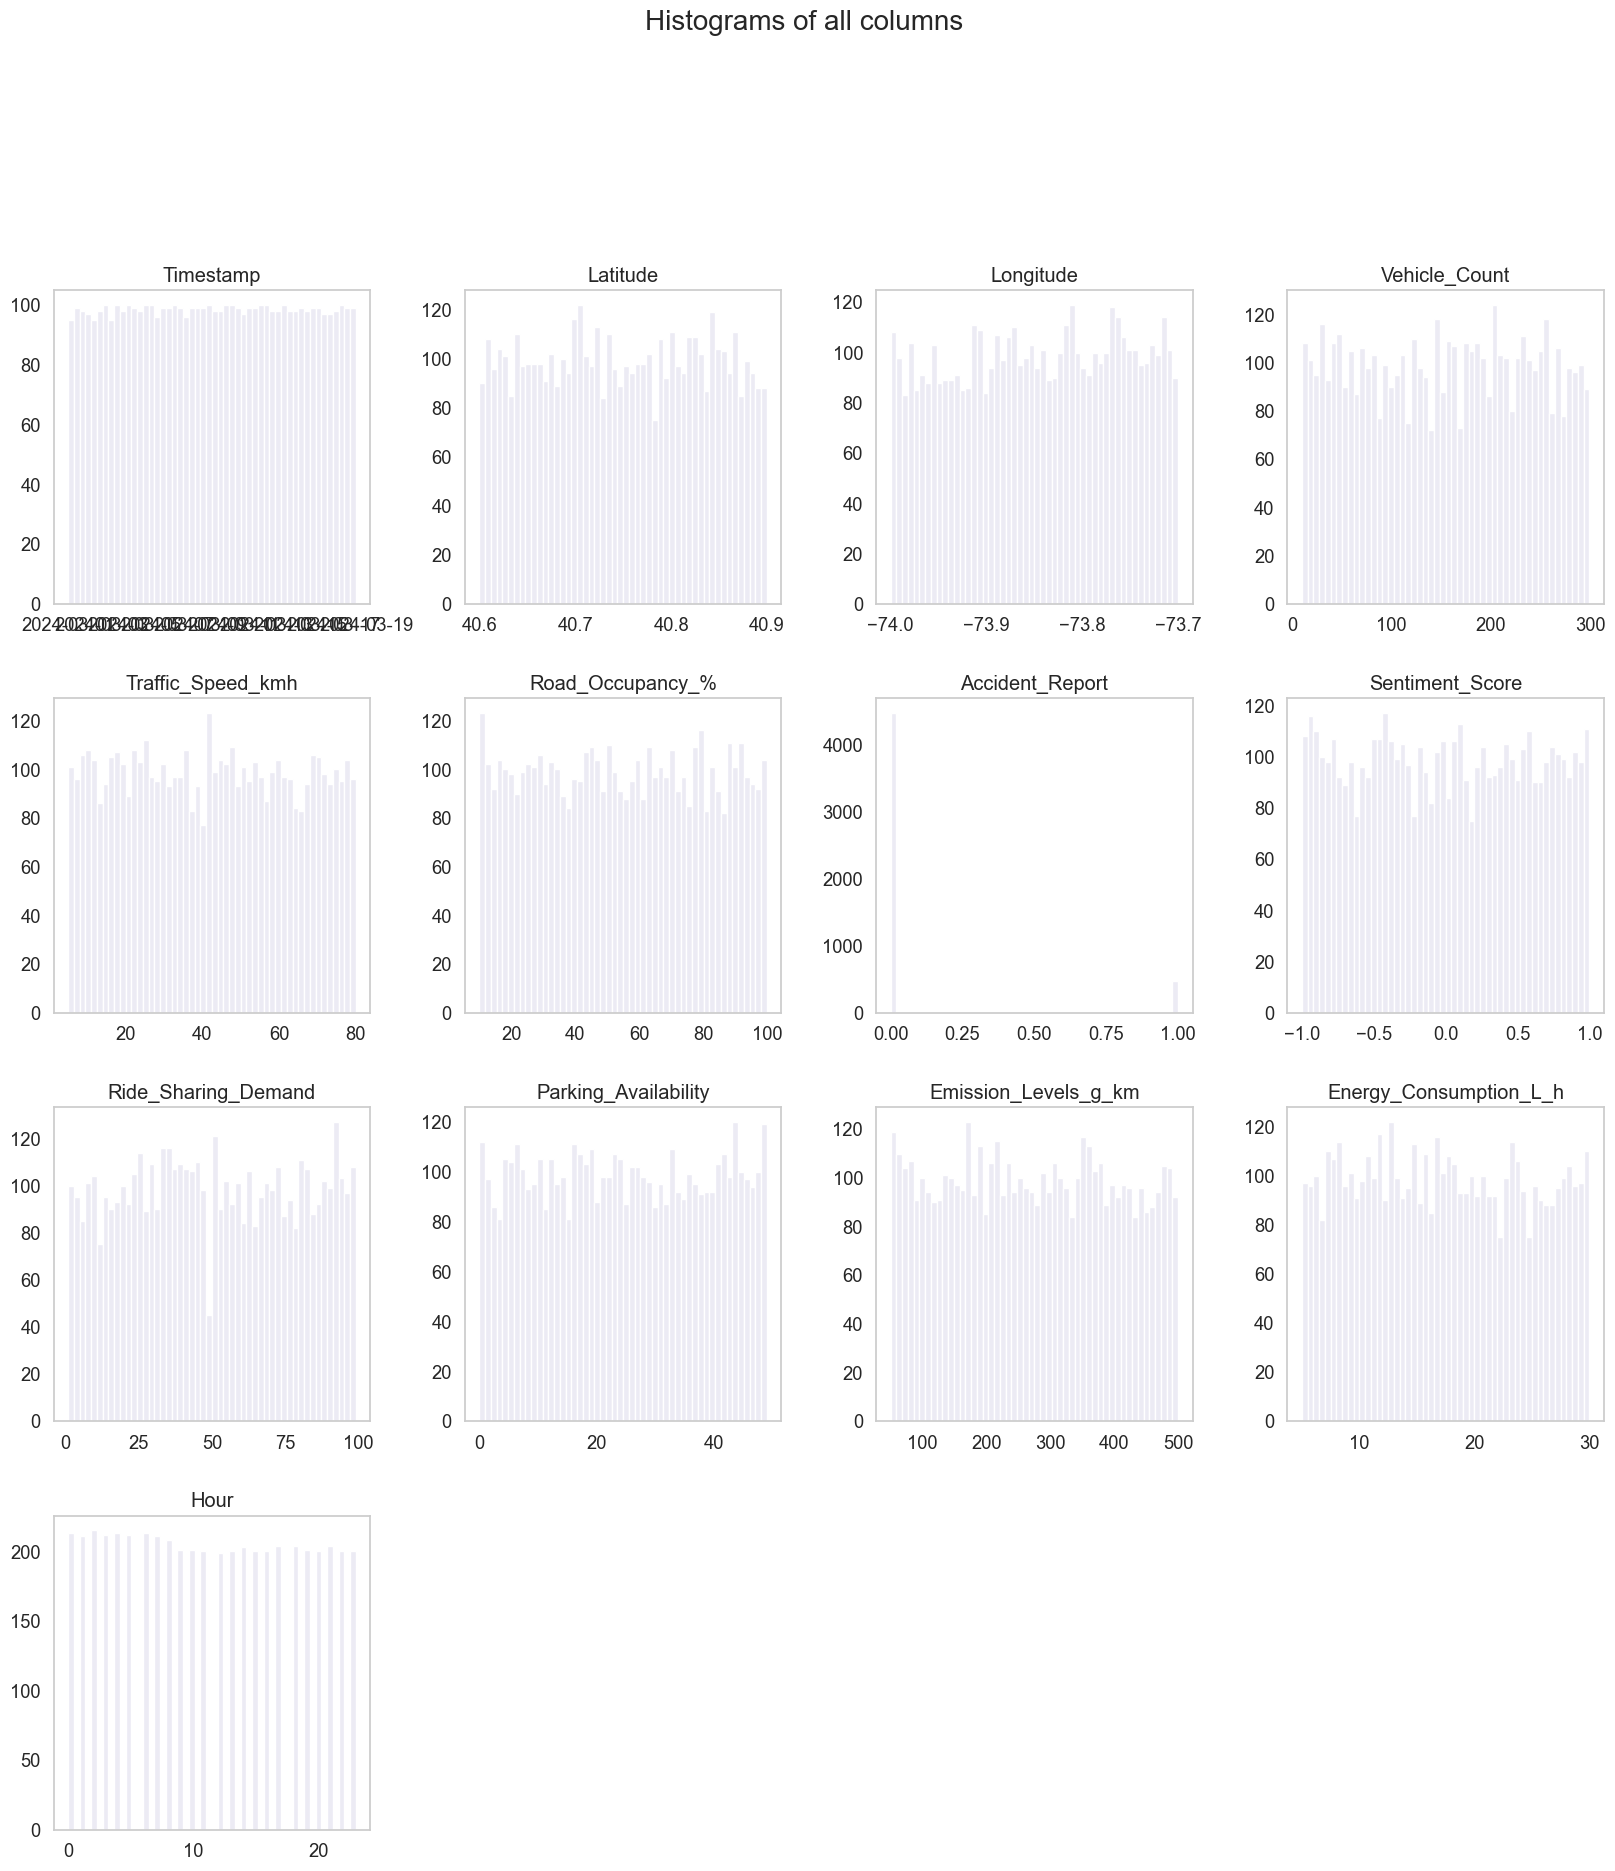

In [ ]:
df.hist(figsize=(20,20), bins=50, grid=False) # Plot histograms for all columns
plt.suptitle("Histograms of all columns", y=1.02, size=20)
plt.show()

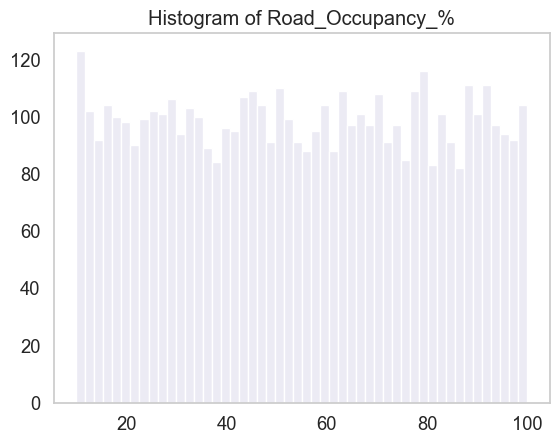

In [ ]:
df['Road_Occupancy_%'].hist(bins=50, grid=False) # Plot histogram for Road_Occupancy_% column
plt.title("Histogram of Road_Occupancy_%")
plt.show()

In [ ]:
df[df['Road_Occupancy']==1]['Vehicle_Count'].hist(bins='auto', color='blue', alpha=0.7, label='Road_Occupancy=1')
df[df['Road_Occupancy']==0]['Vehicle_Count'].hist(bins='auto', color='red', alpha=0.7,, label='Road_Occupancy=0')

KeyError: 'Road_Occupancy'

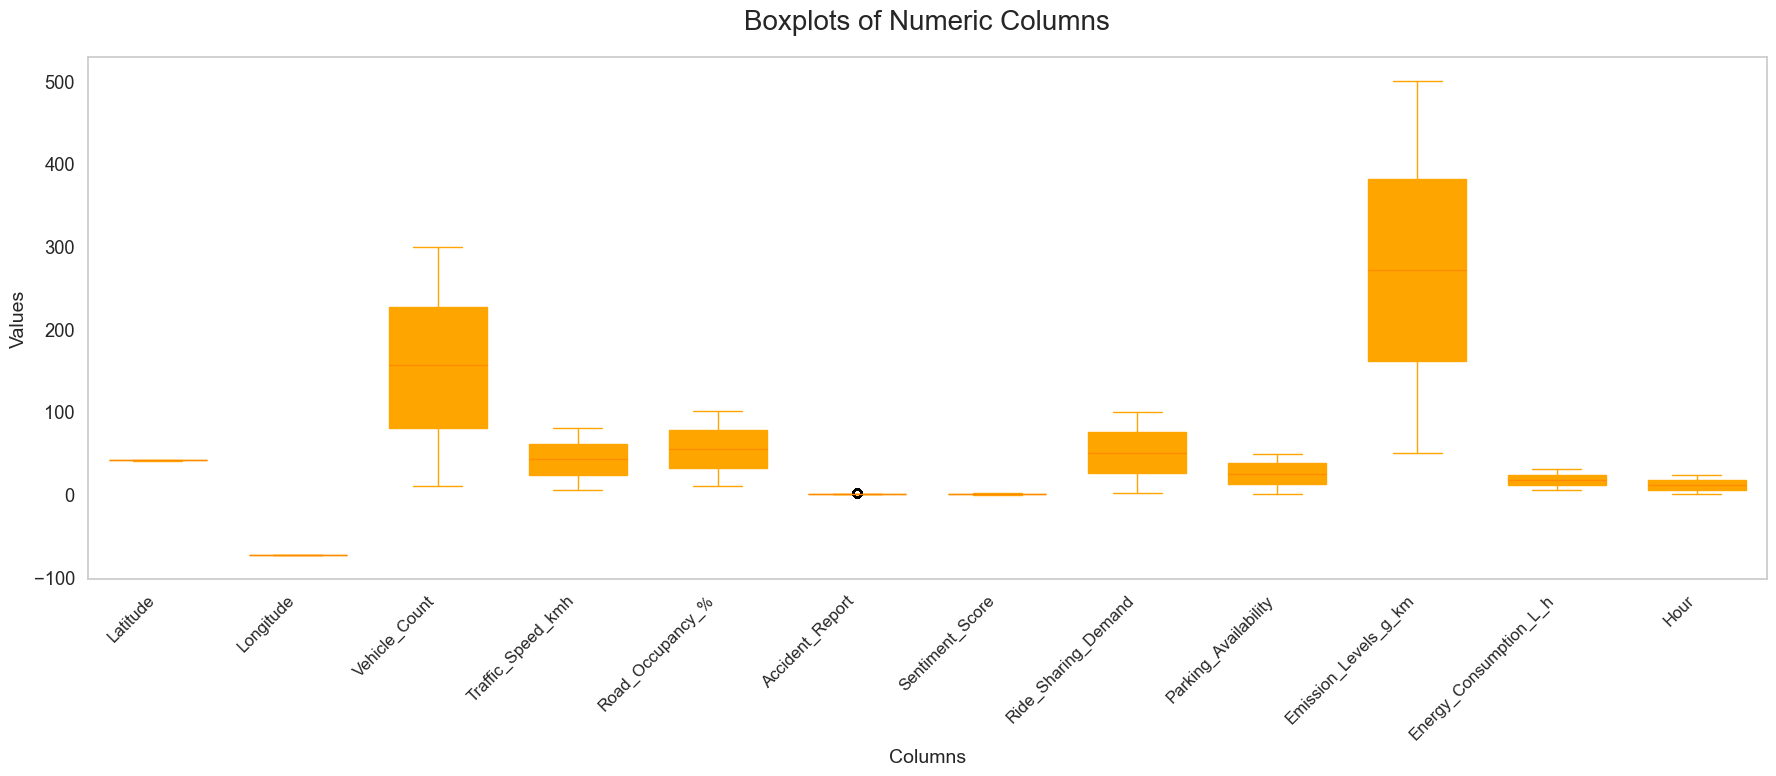

In [ ]:


# Filter numeric columns only (exclude categorical and datetime)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df_numeric = df[numeric_cols]

# Larger figure size with adjusted aspect ratio
plt.figure(figsize=(18, 8))

# Box plot with orange color
box = df_numeric.boxplot(grid=False, color=dict(boxes='orange', whiskers='orange', medians='darkorange', caps='orange'),
                         patch_artist=True,  # Required for filled boxes
                         widths=0.7)  # Wider boxes for visibility

# Customize title and labels
plt.title("Boxplots of Numeric Columns", fontsize=20, pad=20)
plt.xlabel("Columns", fontsize=14)
plt.ylabel("Values", fontsize=14)

# Slant x-axis labels
plt.xticks(rotation=45, ha='right', fontsize=12)  # Slanted at 45 degrees, right-aligned

# Adjust y-axis scale (optional: uncomment and tweak based on your data)
# plt.ylim(df_numeric.min().min() * 1.1, df_numeric.max().max() * 1.1)  # 10% buffer

# Tight layout to prevent clipping
plt.tight_layout()
plt.show()

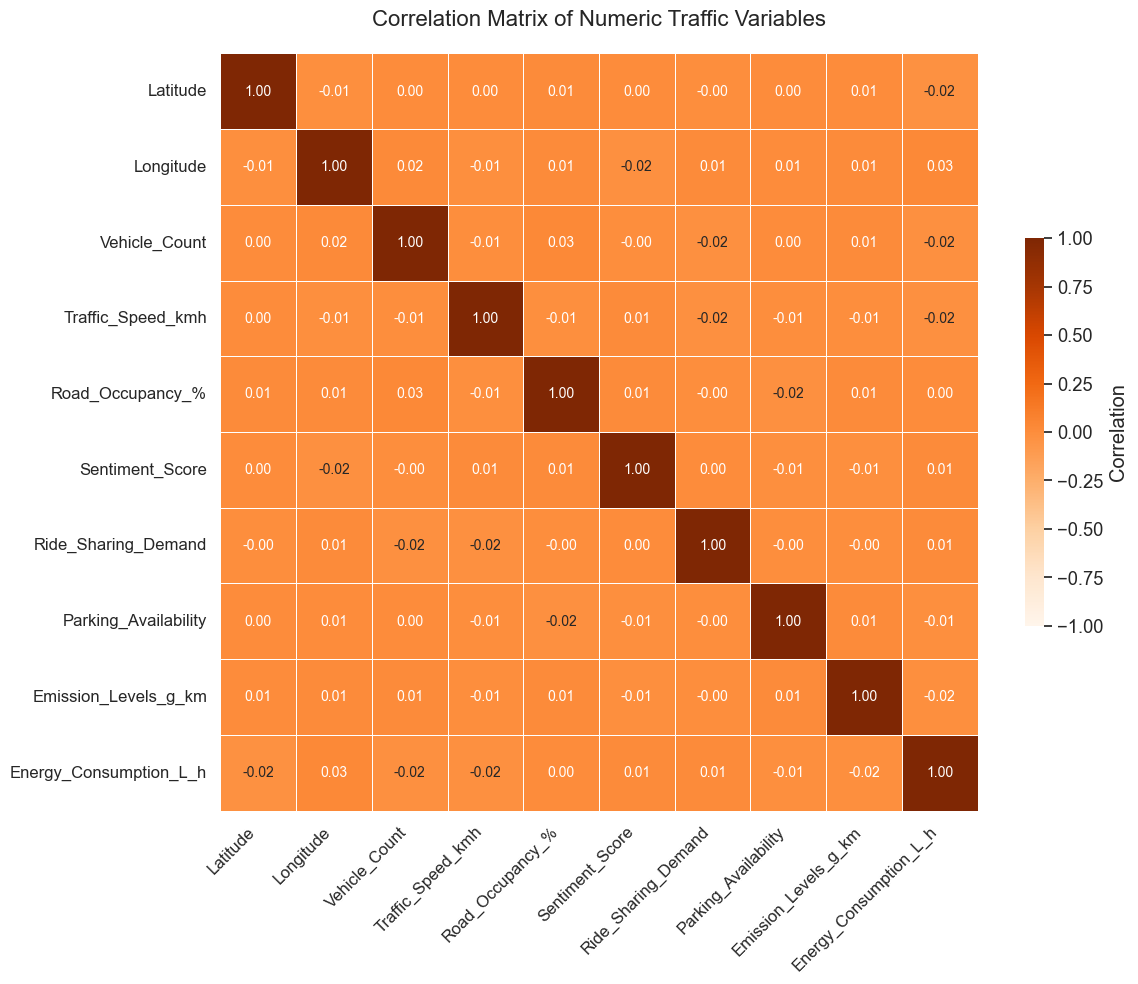

In [ ]:


# Filter numeric columns
numeric_cols = ['Latitude', 'Longitude', 'Vehicle_Count', 'Traffic_Speed_kmh', 'Road_Occupancy_%',
                'Sentiment_Score', 'Ride_Sharing_Demand', 'Parking_Availability',
                'Emission_Levels_g_km', 'Energy_Consumption_L_h']
df_numeric = df[numeric_cols].astype(float)  # Ensure all are float

# Compute correlation matrix
corr_matrix = df_numeric.corr()

# Create heatmap
plt.figure(figsize=(12, 10))  # Square size for symmetry
sns.heatmap(corr_matrix,
            annot=True,  # Show correlation values
            cmap='Oranges',  # Your preferred color scheme
            vmin=-1, vmax=1,  # Full correlation range
            center=0,  # Center colormap at 0
            fmt='.2f',  # 2 decimal places
            square=True,  # Square cells for better proportion
            linewidths=0.5,  # Thin lines between cells
            cbar_kws={'shrink': .5, 'label': 'Correlation'},  # Compact colorbar
            annot_kws={'fontsize': 10})  # Readable annotation size

# Customize title and labels
plt.title('Correlation Matrix of Numeric Traffic Variables', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=12)  # Slanted labels
plt.yticks(rotation=0, fontsize=12)  # Horizontal y-labels for contrast

# Tight layout to prevent clipping
plt.tight_layout()
plt.show()


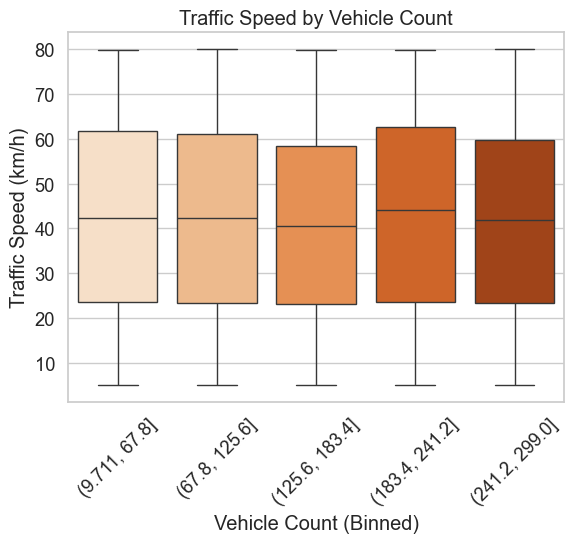

In [ ]:
# Convert columns to float
df['Vehicle_Count'] = df['Vehicle_Count'].astype(float)
df['Traffic_Speed_kmh'] = df['Traffic_Speed_kmh'].astype(float)

# Bin Vehicle_Count into 5 categories
df['Vehicle_Count_Binned'] = pd.cut(df['Vehicle_Count'], bins=5)

# Box Plot (fixing the palette warning)
sns.boxplot(x='Vehicle_Count_Binned', y='Traffic_Speed_kmh', data=df, hue='Vehicle_Count_Binned', palette='Oranges', legend=False)

plt.title('Traffic Speed by Vehicle Count')
plt.xlabel('Vehicle Count (Binned)')
plt.ylabel('Traffic Speed (km/h)')
plt.xticks(rotation=45)
plt.show()

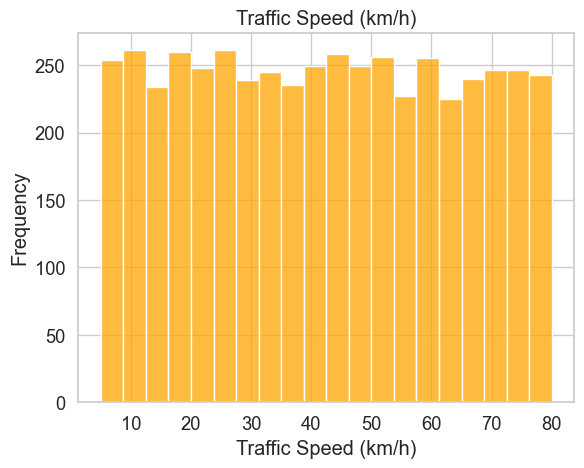

In [ ]:
# Ensure Traffic_Speed_kmh is float
df['Traffic_Speed_kmh'] = df['Traffic_Speed_kmh'].astype(float)

# Histogram using Seaborn
sns.histplot(x='Traffic_Speed_kmh', data=df, bins=20, color='orange')

plt.title('Traffic Speed (km/h)')
plt.xlabel('Traffic Speed (km/h)')
plt.ylabel('Frequency')
plt.show()

/var/folders/_f/952nnrtj2cqfx6j55v126fl80000gn/T/ipykernel_16497/3951072418.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Traffic_Condition', y='Traffic_Speed_kmh', data=df, palette='Oranges')


Text(0.5, 1.0, 'Speed by Traffic Condition')

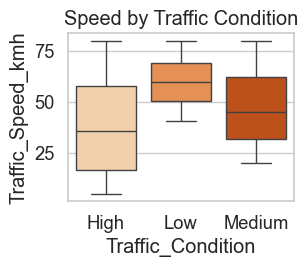

In [ ]:
# 2. Box: Traffic_Speed_kmh vs Traffic_Condition
plt.subplot(2, 2, 2)
sns.boxplot(x='Traffic_Condition', y='Traffic_Speed_kmh', data=df, palette='Oranges')
plt.title('Speed by Traffic Condition')

/var/folders/_f/952nnrtj2cqfx6j55v126fl80000gn/T/ipykernel_16497/131377303.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Traffic_Condition', y='Traffic_Speed_kmh', data=df, palette='Oranges')
/var/folders/_f/952nnrtj2cqfx6j55v126fl80000gn/T/ipykernel_16497/131377303.py:32: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_agg = df.groupby(df['Timestamp'].dt.floor('H'))['Vehicle_Count'].mean().reset_index()


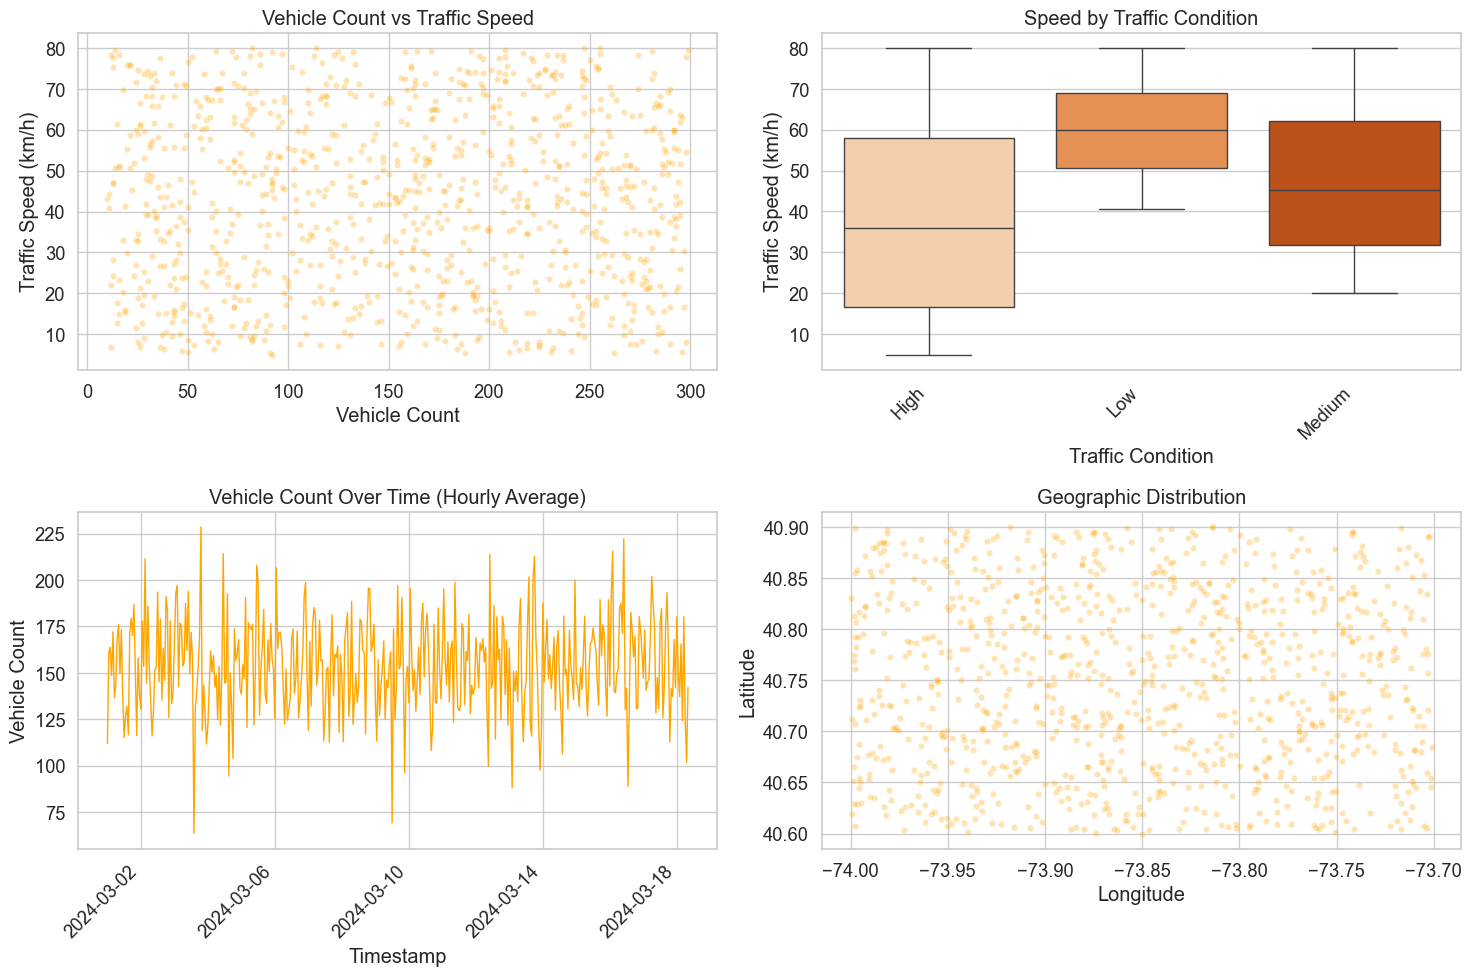

In [ ]:
# Prep data
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Vehicle_Count'] = df['Vehicle_Count'].astype(float)
df['Traffic_Speed_kmh'] = df['Traffic_Speed_kmh'].astype(float)

# Larger figure size for all subplots
plt.figure(figsize=(15, 10))

# 1. Scatter: Vehicle_Count vs Traffic_Speed_kmh (Reduce crowding with transparency and sampling)
plt.subplot(2, 2, 1)
# Sample 1000 points if too crowded (optional: remove if you want all data)
sample_df = df.sample(n=min(1000, len(df)), random_state=42)
sns.scatterplot(x='Vehicle_Count', y='Traffic_Speed_kmh', data=sample_df, color='orange', alpha=0.3, s=20)
plt.title('Vehicle Count vs Traffic Speed')
plt.xlabel('Vehicle Count')
plt.ylabel('Traffic Speed (km/h)')
# Adjust axis limits if needed (example, uncomment if you know your data range)
# plt.xlim(0, df['Vehicle_Count'].max() * 1.1)
# plt.ylim(0, df['Traffic_Speed_kmh'].max() * 1.1)

# 2. Box: Traffic_Speed_kmh vs Traffic_Condition (Fewer categories if needed)
plt.subplot(2, 2, 2)
sns.boxplot(x='Traffic_Condition', y='Traffic_Speed_kmh', data=df, palette='Oranges')
plt.title('Speed by Traffic Condition')
plt.xlabel('Traffic Condition')
plt.ylabel('Traffic Speed (km/h)')
plt.xticks(rotation=45, ha='right')  # Rotate and align labels for readability

# 3. Line: Timestamp vs Vehicle_Count (Aggregate to reduce noise)
plt.subplot(2, 2, 3)
# Aggregate by hour or day to reduce crowding (adjust based on your timestamp frequency)
df_agg = df.groupby(df['Timestamp'].dt.floor('H'))['Vehicle_Count'].mean().reset_index()
plt.plot(df_agg['Timestamp'], df_agg['Vehicle_Count'], color='orange', linewidth=1)
plt.title('Vehicle Count Over Time (Hourly Average)')
plt.xlabel('Timestamp')
plt.ylabel('Vehicle Count')
plt.xticks(rotation=45, ha='right')
# Limit number of ticks for clarity
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(5))

# 4. Scatter: Latitude vs Longitude (Reduce crowding with transparency and sampling)
plt.subplot(2, 2, 4)
sns.scatterplot(x='Longitude', y='Latitude', data=sample_df, color='orange', alpha=0.3, s=20)
plt.title('Geographic Distribution')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

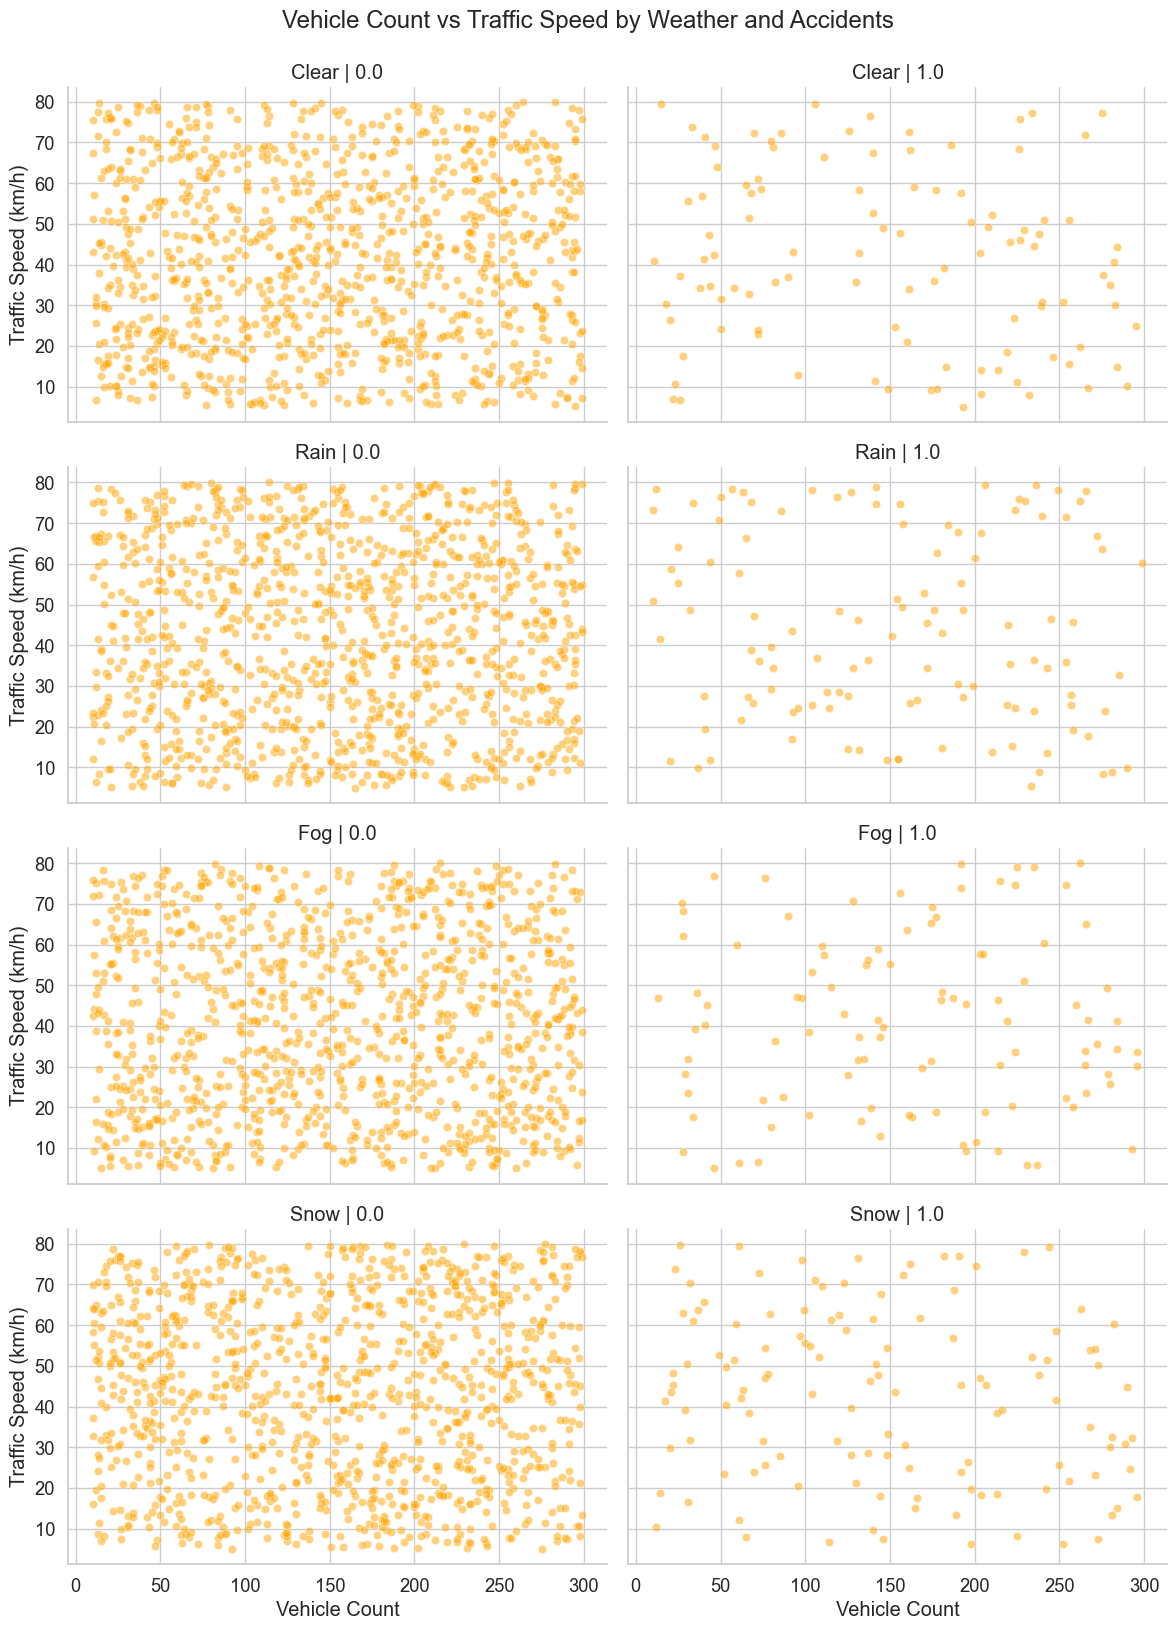

In [ ]:


# Prep data
df['Vehicle_Count'] = df['Vehicle_Count'].astype(float)
df['Traffic_Speed_kmh'] = df['Traffic_Speed_kmh'].astype(float)

# Facet grid
g = sns.FacetGrid(df, row='Weather_Condition', col='Accident_Report', height=4, aspect=1.5)
g.map(sns.scatterplot, 'Vehicle_Count', 'Traffic_Speed_kmh', color='orange', alpha=0.5)
g.set_titles(row_template='{row_name}', col_template='{col_name}')
g.set_axis_labels('Vehicle Count', 'Traffic Speed (km/h)')
g.fig.suptitle('Vehicle Count vs Traffic Speed by Weather and Accidents', y=1.02)
plt.show()



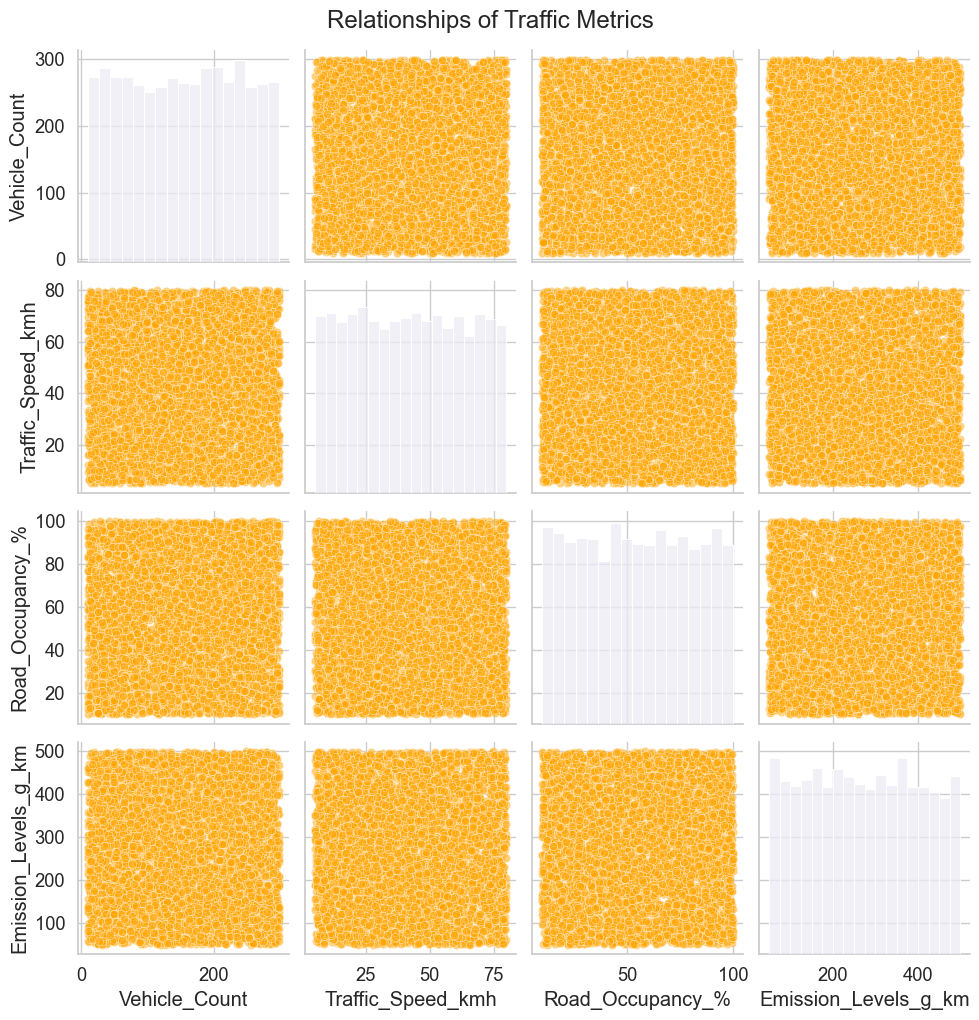

In [ ]:


# Prep data
numeric_cols = ['Vehicle_Count', 'Traffic_Speed_kmh', 'Road_Occupancy_%', 'Emission_Levels_g_km']
df[numeric_cols] = df[numeric_cols].astype(float)

# Pair plot
sns.pairplot(df[numeric_cols], diag_kind='hist', plot_kws={'color': 'orange', 'alpha': 0.5})
plt.suptitle('Relationships of Traffic Metrics', y=1.02)
plt.show()

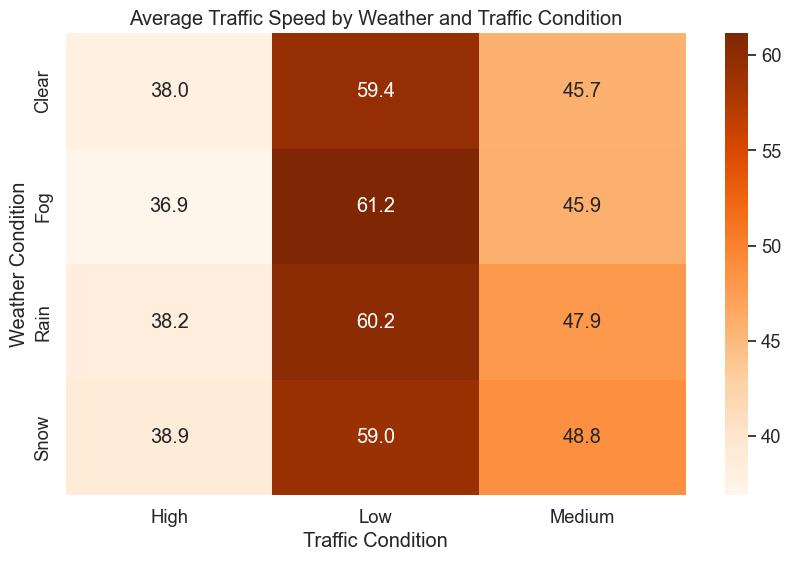

In [ ]:
# Aggregate data
heatmap_data = df.groupby(['Weather_Condition', 'Traffic_Condition'])['Traffic_Speed_kmh'].mean().unstack()

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap='Oranges', fmt='.1f')
plt.title('Average Traffic Speed by Weather and Traffic Condition')
plt.xlabel('Traffic Condition')
plt.ylabel('Weather Condition')
plt.show()

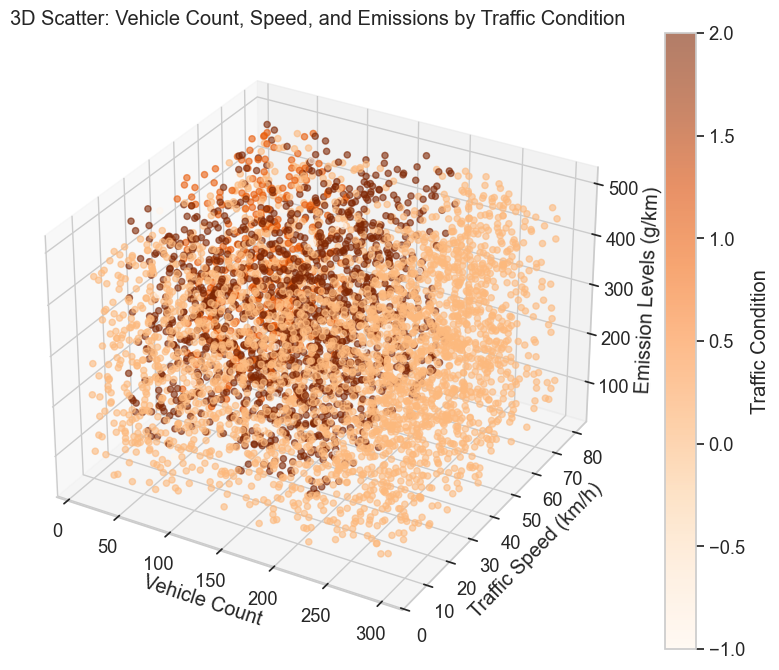

In [ ]:
# Prep data
df['Vehicle_Count'] = df['Vehicle_Count'].astype(float)
df['Traffic_Speed_kmh'] = df['Traffic_Speed_kmh'].astype(float)
df['Emission_Levels_g_km'] = df['Emission_Levels_g_km'].astype(float)

# 3D Scatter
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df['Vehicle_Count'], df['Traffic_Speed_kmh'], df['Emission_Levels_g_km'],
                     c=pd.factorize(df['Traffic_Condition'])[0], cmap='Oranges', alpha=0.6)

ax.set_xlabel('Vehicle Count')
ax.set_ylabel('Traffic Speed (km/h)')
ax.set_zlabel('Emission Levels (g/km)')
plt.title('3D Scatter: Vehicle Count, Speed, and Emissions by Traffic Condition')
plt.colorbar(scatter, label='Traffic Condition')
plt.show()

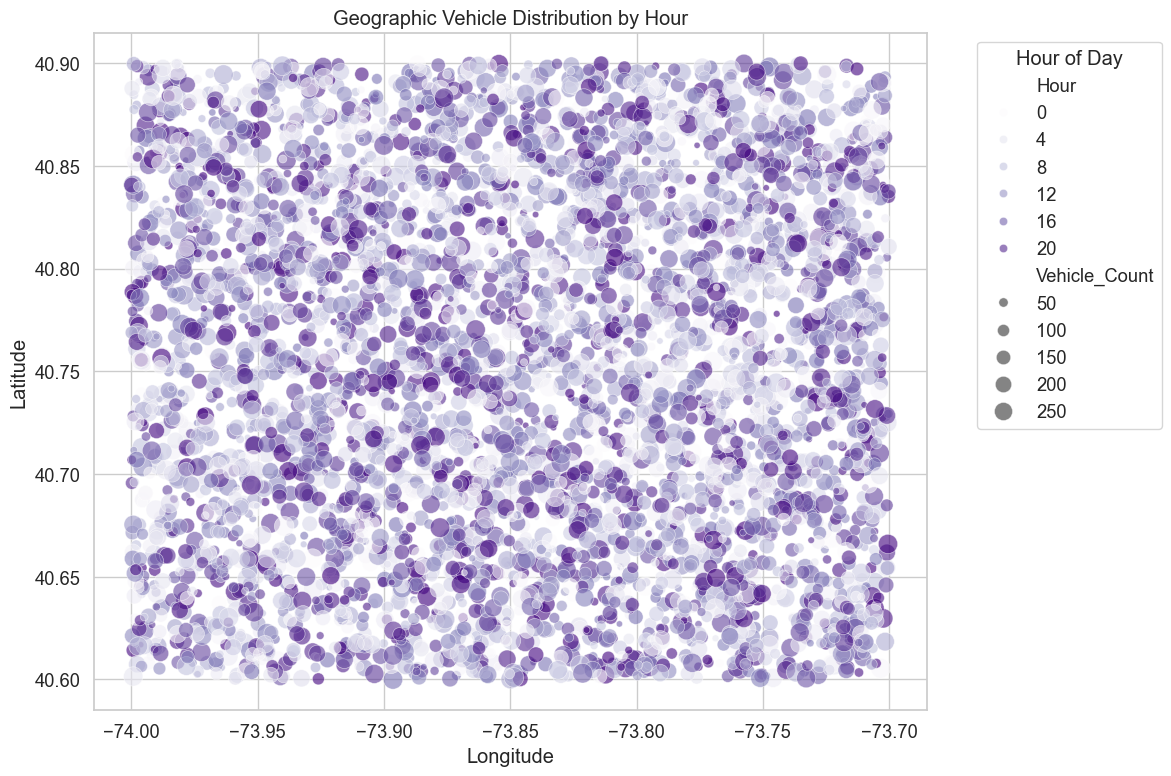

In [ ]:
# Prep data
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour  # Extract hour for hue
df['Vehicle_Count'] = df['Vehicle_Count'].astype(float)
df['Latitude'] = df['Latitude'].astype(float)
df['Longitude'] = df['Longitude'].astype(float)

# Bubble plot
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Longitude', y='Latitude', size='Vehicle_Count', hue='Hour',
                data=df, palette='Purples', alpha=0.6, sizes=(20, 200))

plt.title('Geographic Vehicle Distribution by Hour')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Hour of Day', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

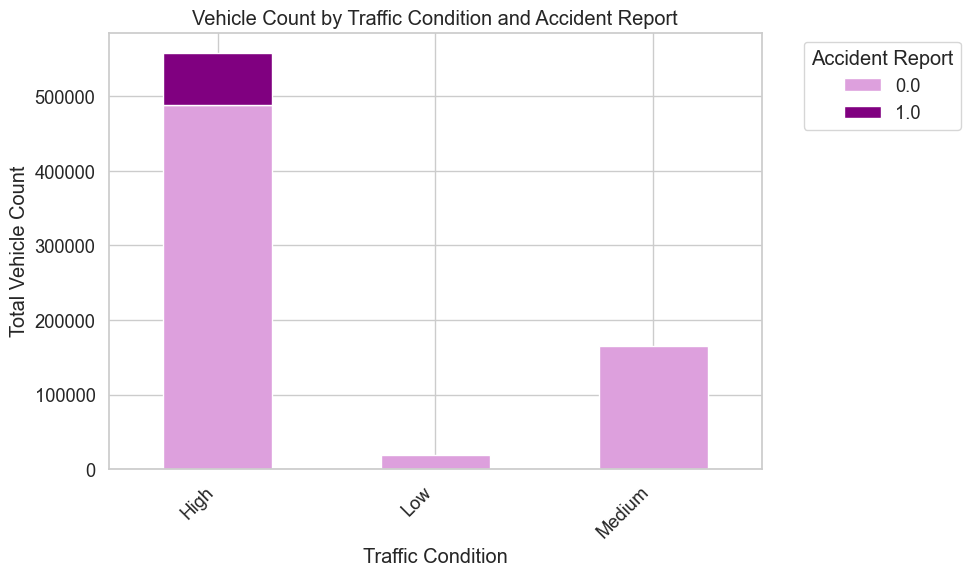

In [ ]:
# Aggregate data
stacked_data = df.groupby(['Traffic_Condition', 'Accident_Report'])['Vehicle_Count'].sum().unstack()

# Stacked bar plot
plt.figure(figsize=(10, 6))
stacked_data.plot(kind='bar', stacked=True, color=['#DDA0DD', '#800080'], figsize=(10, 6))  # Shades of purple
plt.title('Vehicle Count by Traffic Condition and Accident Report')
plt.xlabel('Traffic Condition')
plt.ylabel('Total Vehicle Count')
plt.legend(title='Accident Report', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/Users/phionanamugga/Documents/coding/datascience/EDA_Smart_Mobility_Traffic_Dataset/venv/lib/python3.13/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the violinplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/Users/phionanamugga/Documents/coding/datascience/EDA_Smart_Mobility_Traffic_Dataset/venv/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/Users/phionanamugga/Documents/coding/datascience/EDA_Smart_Mobility_Traffic_Dataset/venv/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)

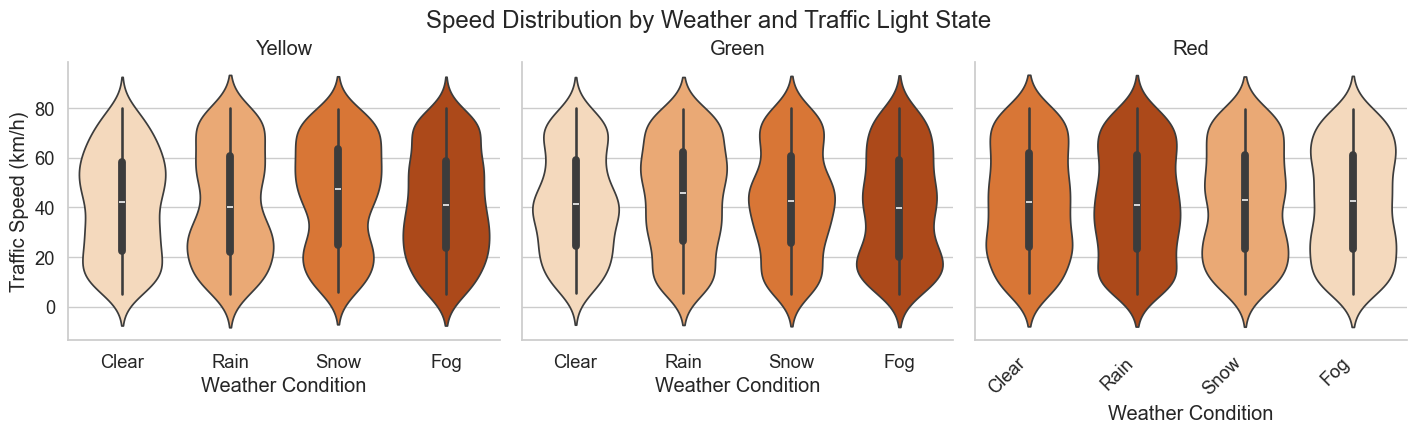

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prep data
df['Traffic_Speed_kmh'] = df['Traffic_Speed_kmh'].astype(float)

# Faceted violin plot
g = sns.FacetGrid(df, col='Traffic_Light_State', height=4, aspect=1.2)
g.map(sns.violinplot, 'Weather_Condition', 'Traffic_Speed_kmh', palette='Oranges')
g.set_titles('{col_name}')
g.set_axis_labels('Weather Condition', 'Traffic Speed (km/h)')
g.fig.suptitle('Speed Distribution by Weather and Traffic Light State', y=1.02)
plt.xticks(rotation=45, ha='right')
plt.show()

/var/folders/_f/952nnrtj2cqfx6j55v126fl80000gn/T/ipykernel_16497/544338313.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_agg = df.groupby([df['Timestamp'].dt.floor('H'), 'Traffic_Condition'])[['Traffic_Speed_kmh', 'Ride_Sharing_Demand']].mean().reset_index()
/var/folders/_f/952nnrtj2cqfx6j55v126fl80000gn/T/ipykernel_16497/544338313.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Traffic Condition', bbox_to_anchor=(1.05, 1), loc='upper left')


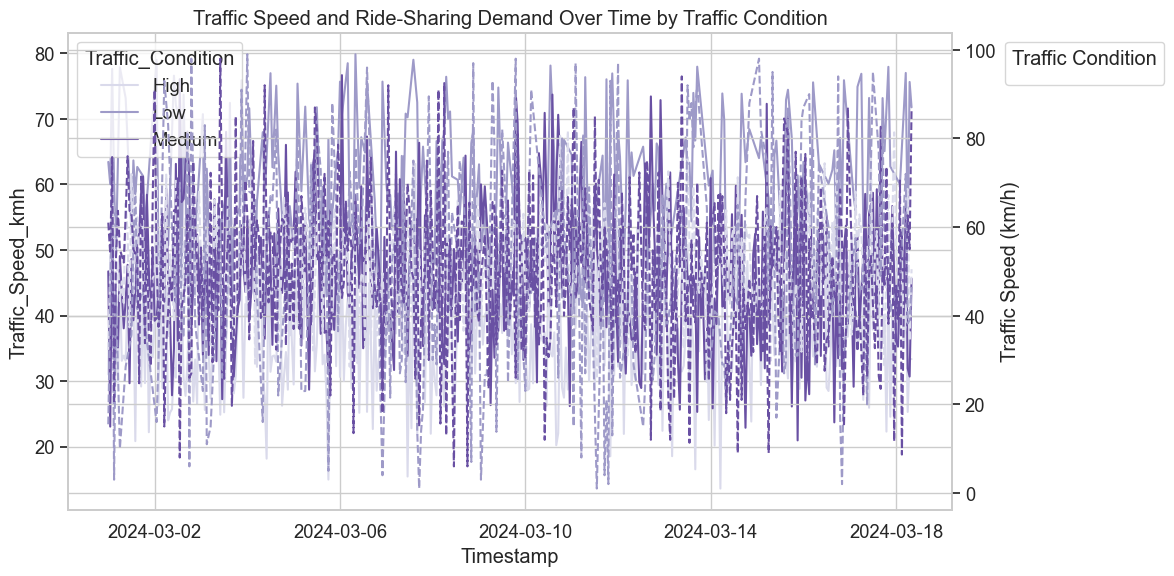

In [ ]:

# Prep data
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Traffic_Speed_kmh'] = df['Traffic_Speed_kmh'].astype(float)
df['Ride_Sharing_Demand'] = df['Ride_Sharing_Demand'].astype(float)

# Aggregate by hour
df_agg = df.groupby([df['Timestamp'].dt.floor('H'), 'Traffic_Condition'])[['Traffic_Speed_kmh', 'Ride_Sharing_Demand']].mean().reset_index()

# Multi-line plot
plt.figure(figsize=(12, 6))
sns.lineplot(x='Timestamp', y='Traffic_Speed_kmh', hue='Traffic_Condition', data=df_agg, palette='Purples', legend='brief')
ax2 = plt.twinx()  # Second y-axis
sns.lineplot(x='Timestamp', y='Ride_Sharing_Demand', hue='Traffic_Condition', data=df_agg, palette='Purples', ax=ax2, legend=False, linestyle='--')
plt.title('Traffic Speed and Ride-Sharing Demand Over Time by Traffic Condition')
plt.xlabel('Timestamp')
ax2.set_ylabel('Ride-Sharing Demand')
plt.ylabel('Traffic Speed (km/h)')
plt.xticks(rotation=45, ha='right')
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(6))
plt.legend(title='Traffic Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

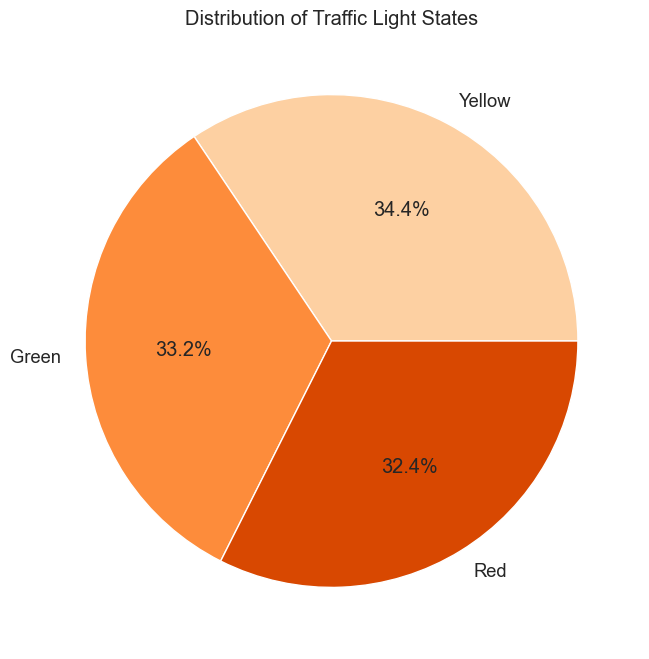

In [ ]:
# Count occurrences of each Traffic_Light_State
traffic_light_counts = df['Traffic_Light_State'].value_counts()

# Pie chart
plt.figure(figsize=(8, 8))
plt.pie(traffic_light_counts, labels=traffic_light_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('Oranges', len(traffic_light_counts)))
plt.title('Distribution of Traffic Light States')
plt.show()

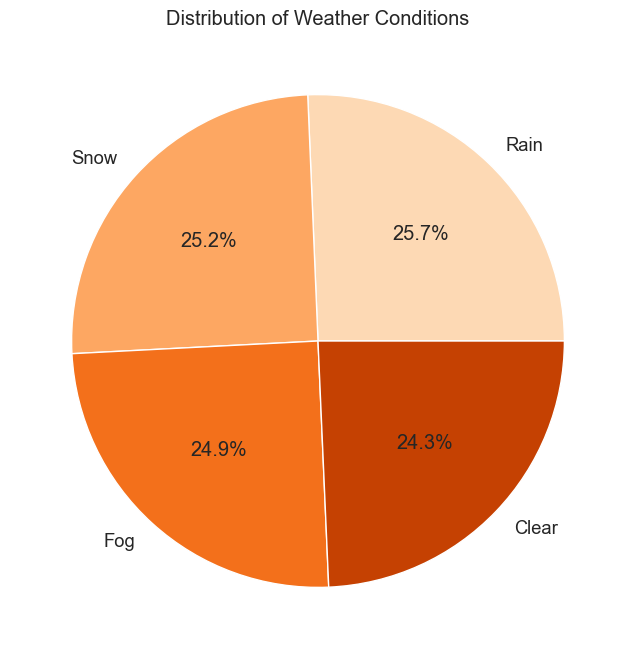

In [ ]:
# Count occurrences of each Weather_Condition
weather_counts = df['Weather_Condition'].value_counts()

# Pie chart
plt.figure(figsize=(8, 8))
plt.pie(weather_counts, labels=weather_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('Oranges', len(weather_counts)))
plt.title('Distribution of Weather Conditions')
plt.show()

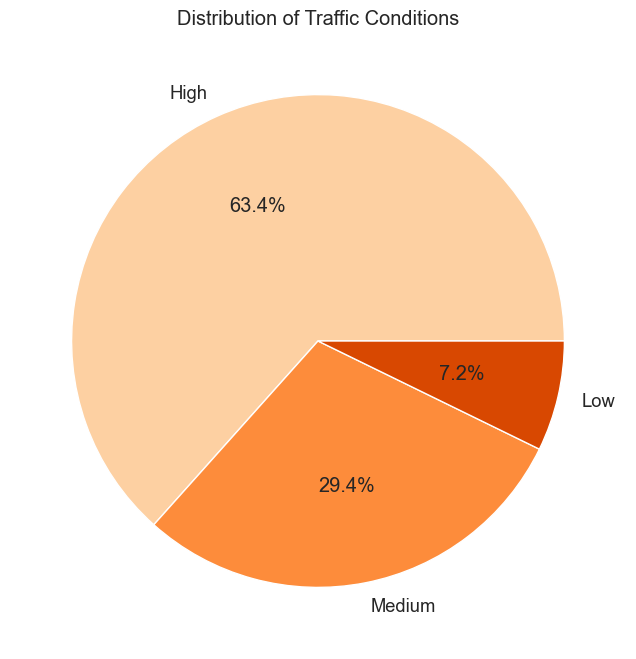

In [ ]:
# Count occurrences of each Traffic_Condition
traffic_condition_counts = df['Traffic_Condition'].value_counts()

# Pie chart
plt.figure(figsize=(8, 8))
plt.pie(traffic_condition_counts, labels=traffic_condition_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('Oranges', len(traffic_condition_counts)))
plt.title('Distribution of Traffic Conditions')
plt.show()

In [ ]:
# 2. Summary Statistics
print("\nNumeric Summary:")
print(df[numeric_cols].describe())
print("\nCategorical Counts:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Numeric Summary:
          Latitude    Longitude  Vehicle_Count  Traffic_Speed_kmh  \
count  4947.000000  4925.000000    4927.000000        4931.000000   
mean     40.749537   -73.847407     153.866044          42.210544   
std       0.086091     0.086148      83.611289          21.681495   
min      40.600016   -73.999906      10.000000           5.002789   
25%      40.675375   -73.919971      80.000000          23.410557   
50%      40.748536   -73.845912     156.000000          42.370915   
75%      40.824719   -73.771690     226.000000          60.825507   
max      40.899972   -73.700159     299.000000          79.997556   

       Road_Occupancy_%  Sentiment_Score  Ride_Sharing_Demand  \
count       4941.000000      4929.000000          4929.000000   
mean          54.772394        -0.005020            50.358491   
std           26.138992         0.583732            28.450735   
min           10.005031        -0.999819             1.000000   
25%           32.107815        -0.4

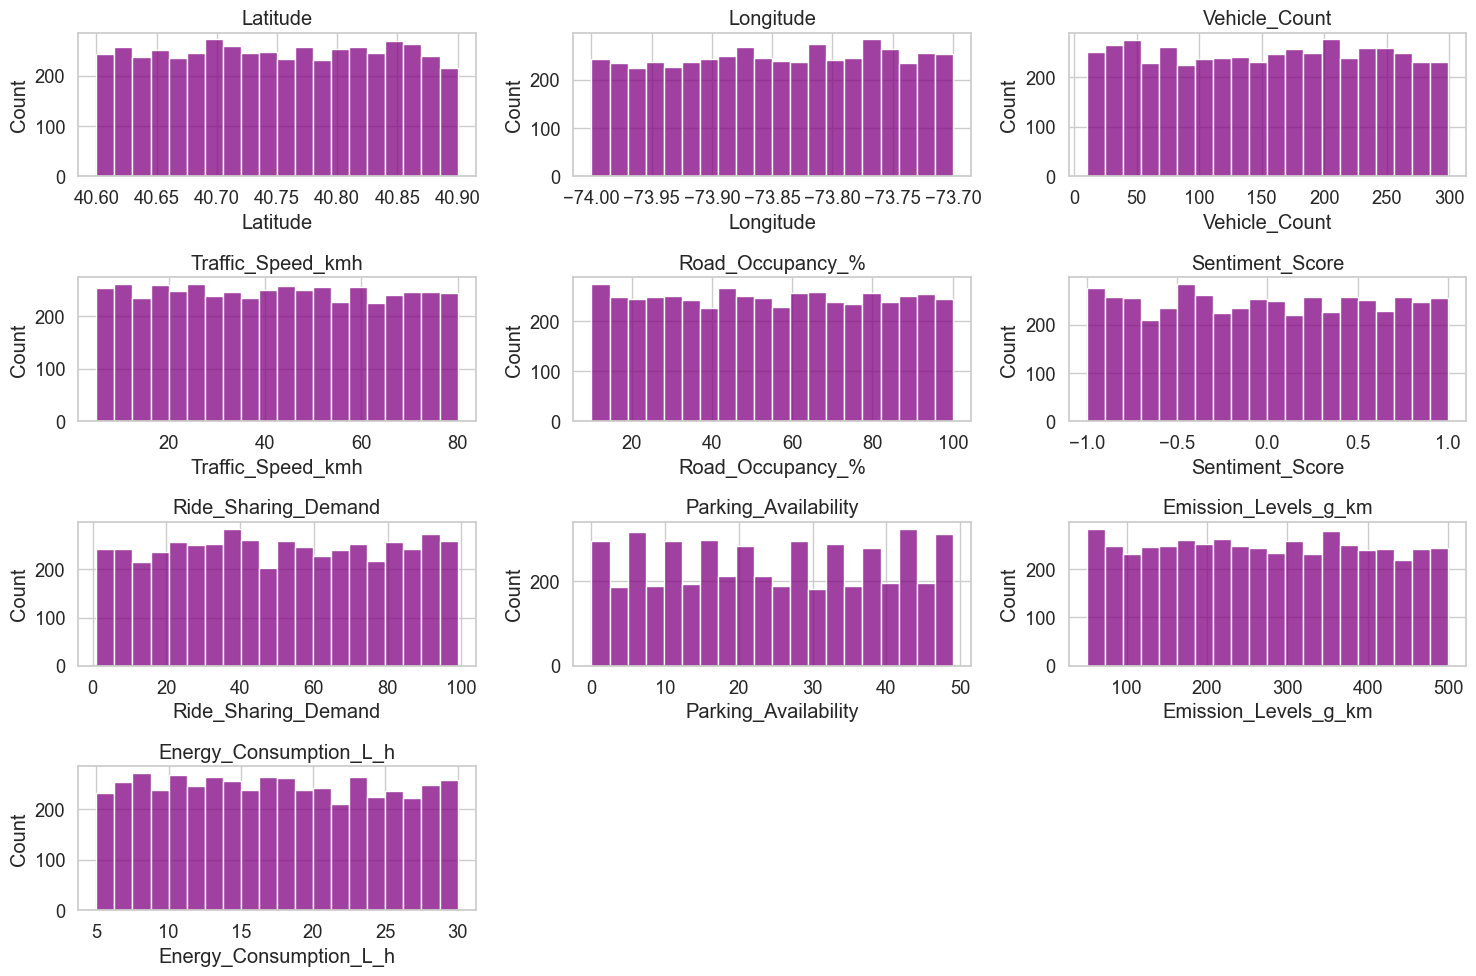

In [ ]:
# 3. Univariate Analysis
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col], bins=20, color='purple')
    plt.title(f'{col}')
plt.tight_layout()
plt.show()

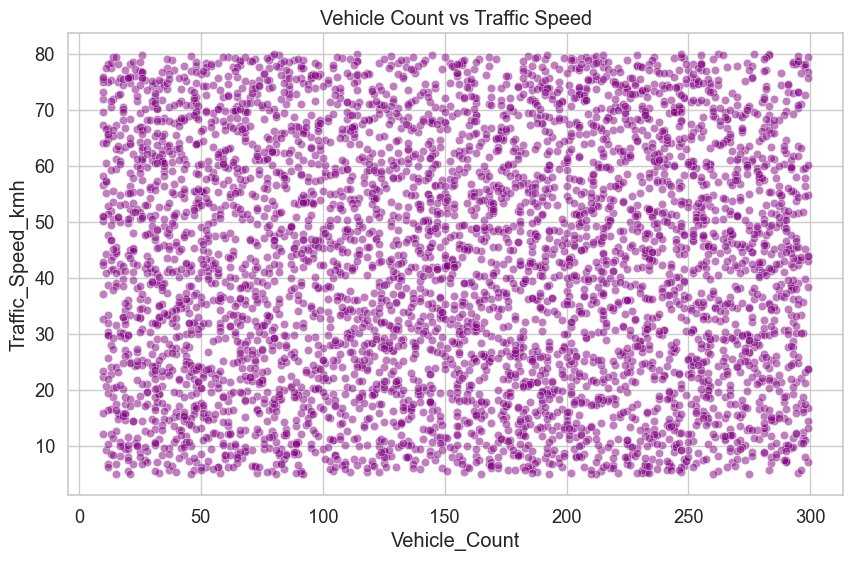

/var/folders/_f/952nnrtj2cqfx6j55v126fl80000gn/T/ipykernel_16497/3216275281.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Traffic_Condition', y='Traffic_Speed_kmh', data=df, palette='Purples')


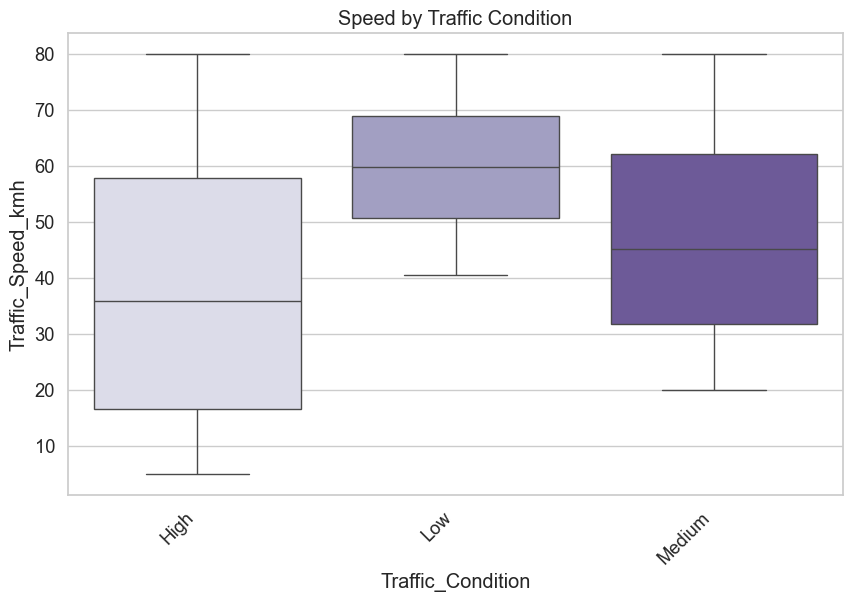

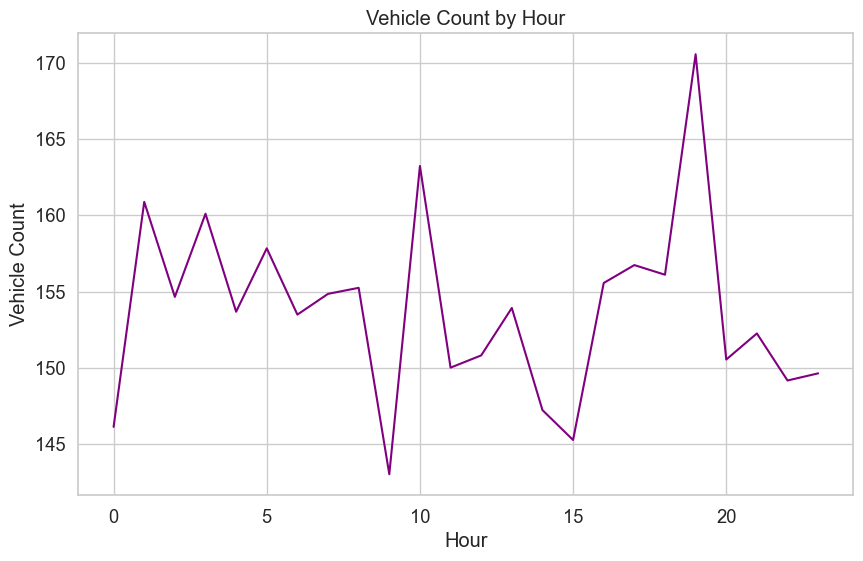

In [ ]:
# 4. Bivariate Analysis
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Vehicle_Count', y='Traffic_Speed_kmh', data=df, color='purple', alpha=0.5)
plt.title('Vehicle Count vs Traffic Speed')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='Traffic_Condition', y='Traffic_Speed_kmh', data=df, palette='Purples')
plt.title('Speed by Traffic Condition')
plt.xticks(rotation=45, ha='right')
plt.show()

df_agg = df.groupby(df['Timestamp'].dt.hour)['Vehicle_Count'].mean()
plt.figure(figsize=(10, 6))
plt.plot(df_agg.index, df_agg.values, color='purple')
plt.title('Vehicle Count by Hour')
plt.xlabel('Hour')
plt.ylabel('Vehicle Count')
plt.show()

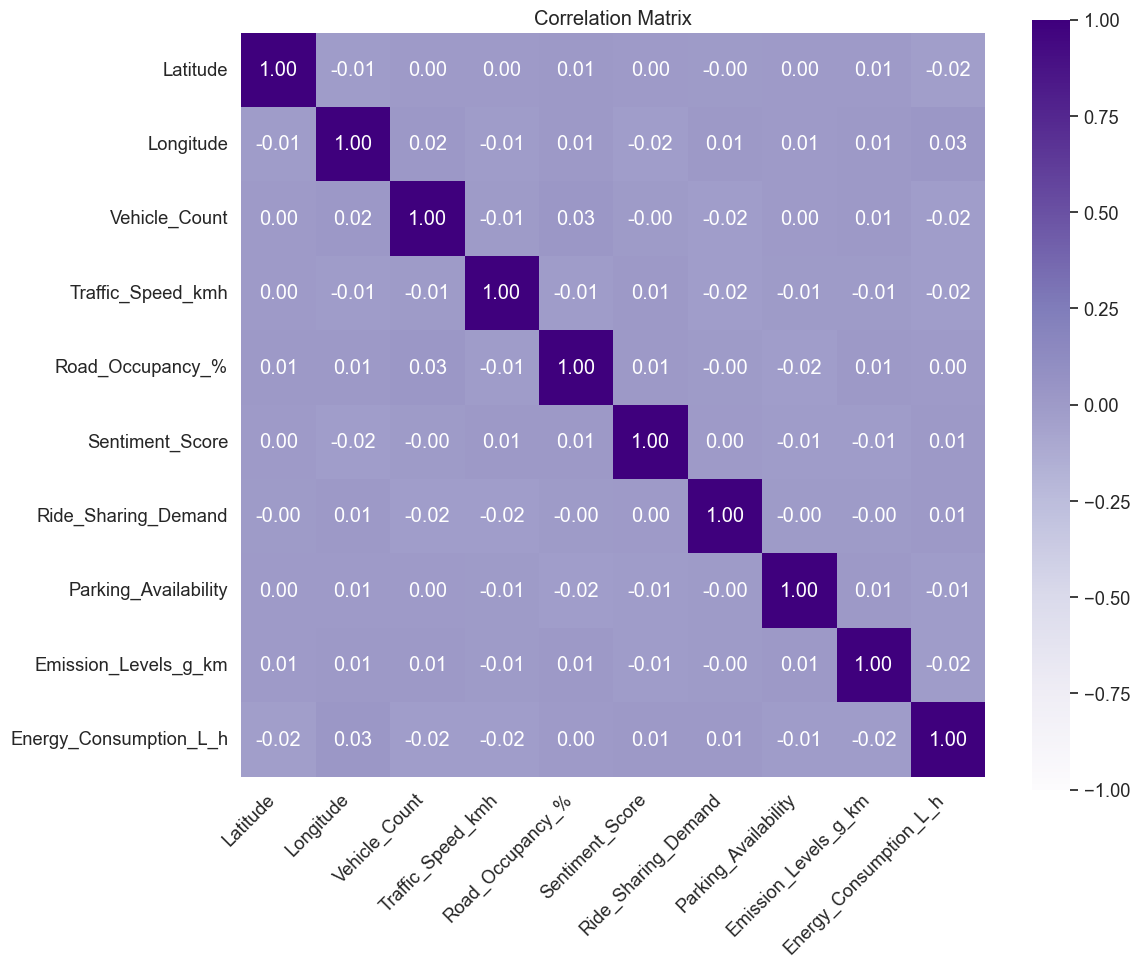

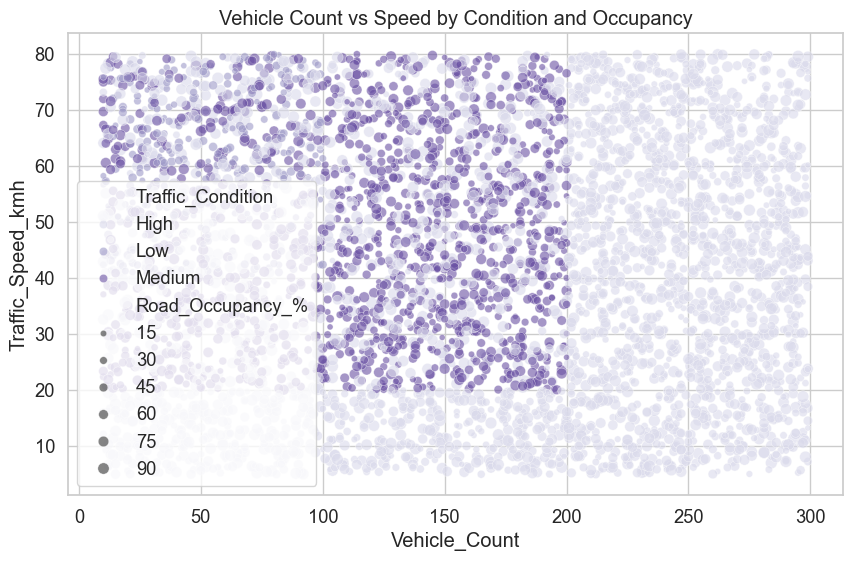

In [ ]:
# 5. Multivariate Analysis
plt.figure(figsize=(12, 10))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='Purples', vmin=-1, vmax=1, fmt='.2f', square=True)
plt.title('Correlation Matrix')
plt.xticks(rotation=45, ha='right')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Vehicle_Count', y='Traffic_Speed_kmh', hue='Traffic_Condition',
                size='Road_Occupancy_%', data=df, palette='Purples', alpha=0.6)
plt.title('Vehicle Count vs Speed by Condition and Occupancy')
plt.show()

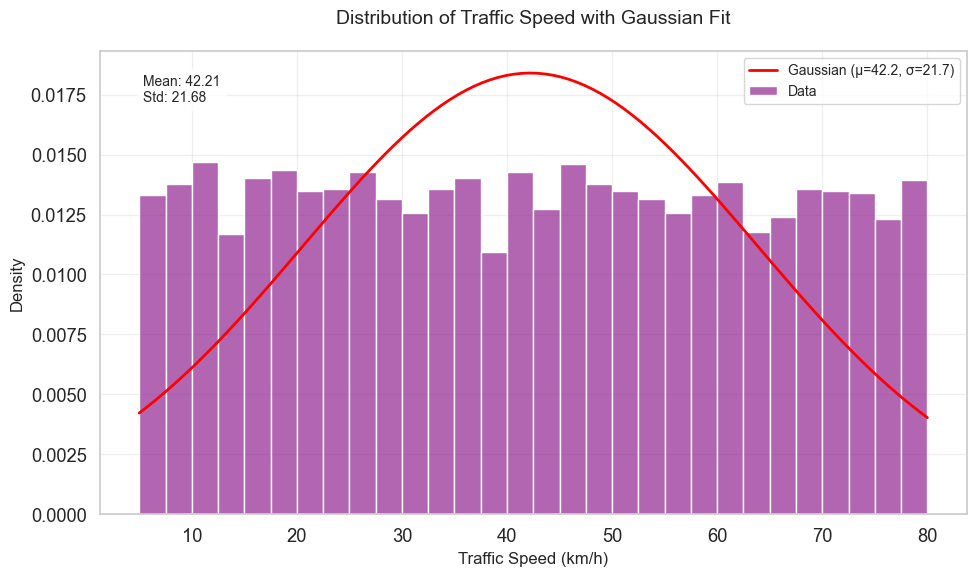

In [ ]:


# Prep data
df['Traffic_Speed_kmh'] = df['Traffic_Speed_kmh'].astype(float)

# Calculate mean and standard deviation
mu = df['Traffic_Speed_kmh'].mean()
sigma = df['Traffic_Speed_kmh'].std()

# Create figure
plt.figure(figsize=(10, 6))

# Plot histogram with density (normalized)
sns.histplot(df['Traffic_Speed_kmh'], bins=30, color='purple', stat='density', alpha=0.6, label='Data')

# Generate points for Gaussian curve
x = np.linspace(df['Traffic_Speed_kmh'].min(), df['Traffic_Speed_kmh'].max(), 100)
gaussian = norm.pdf(x, mu, sigma)
plt.plot(x, gaussian, 'r-', lw=2, label=f'Gaussian (μ={mu:.1f}, σ={sigma:.1f})')

# Customize plot
plt.title('Distribution of Traffic Speed with Gaussian Fit', fontsize=14, pad=20)
plt.xlabel('Traffic Speed (km/h)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)  # Light grid for reference
plt.tight_layout()

# Display mean and std on plot (optional)
plt.text(0.05, 0.95, f'Mean: {mu:.2f}\nStd: {sigma:.2f}', transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))

plt.show()

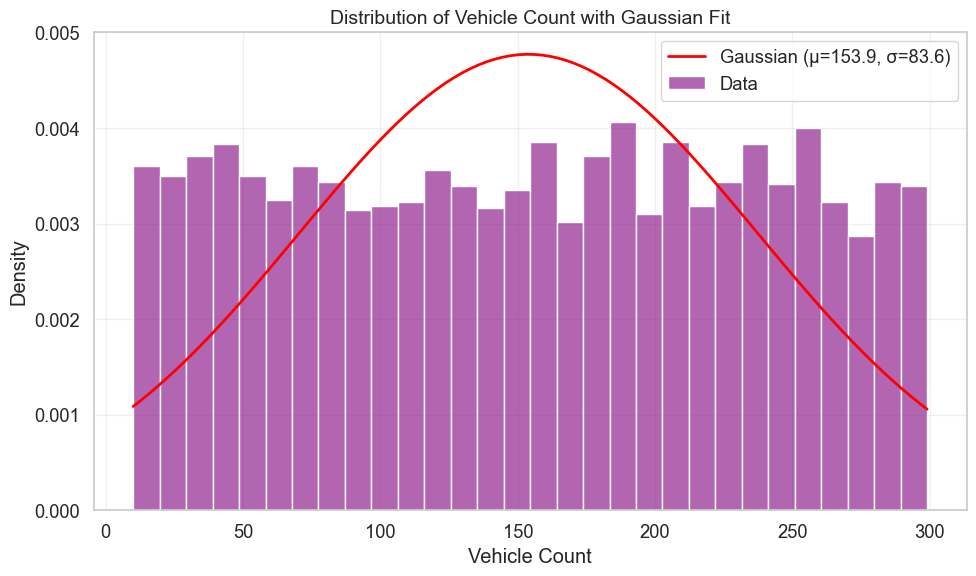

In [ ]:
# Example with Vehicle_Count
mu = df['Vehicle_Count'].mean()
sigma = df['Vehicle_Count'].std()
plt.figure(figsize=(10, 6))
sns.histplot(df['Vehicle_Count'], bins=30, color='purple',stat='density', alpha=0.6, label='Data')
x = np.linspace(df['Vehicle_Count'].min(), df['Vehicle_Count'].max(), 100)
plt.plot(x, norm.pdf(x, mu, sigma), 'r-', lw=2, label=f'Gaussian (μ={mu:.1f}, σ={sigma:.1f})')
plt.title('Distribution of Vehicle Count with Gaussian Fit', fontsize=14)
plt.xlabel('Vehicle Count')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import shapiro
stat, p = shapiro(df['Traffic_Speed_kmh'])
print(f'Shapiro Test: p-value={p:.4f}')  # p > 0.05 suggests normality

Shapiro Test: p-value=nan



Balance Check for 'Traffic_Light_State':
Counts:
 Traffic_Light_State
Yellow    1695
Green     1633
Red       1597
Name: count, dtype: int64
Percentages:
 Traffic_Light_State
Yellow    33.90
Green     32.66
Red       31.94
Name: count, dtype: float64
Imbalance Ratio (max/min): 1.06
-> Relatively Balanced


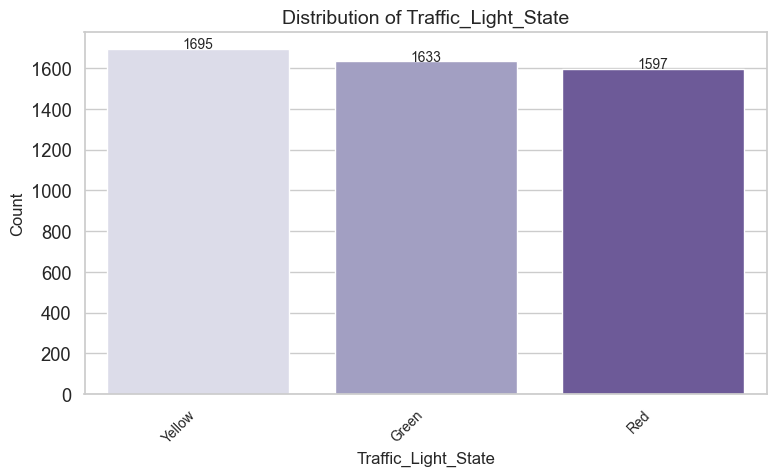


Balance Check for 'Weather_Condition':
Counts:
 Weather_Condition
Rain     1266
Snow     1241
Fog      1227
Clear    1199
Name: count, dtype: int64
Percentages:
 Weather_Condition
Rain     25.32
Snow     24.82
Fog      24.54
Clear    23.98
Name: count, dtype: float64
Imbalance Ratio (max/min): 1.06
-> Relatively Balanced


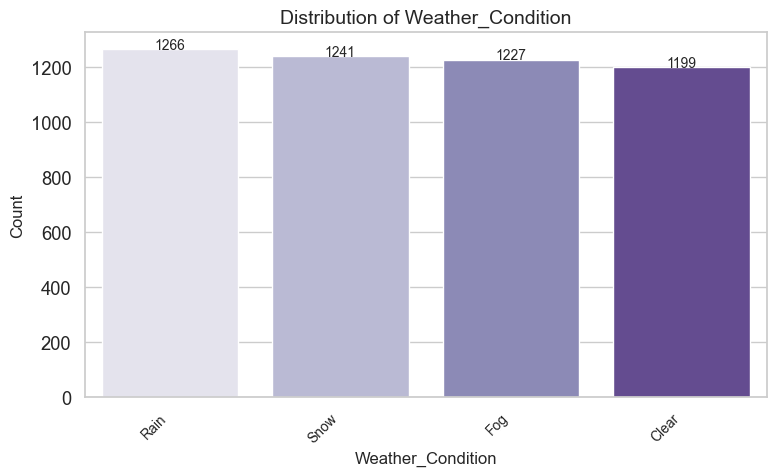


Balance Check for 'Accident_Report':
Counts:
 Accident_Report
0.0    4465
1.0     475
Name: count, dtype: int64
Percentages:
 Accident_Report
0.0    89.3
1.0     9.5
Name: count, dtype: float64
Imbalance Ratio (max/min): 9.40
-> Highly Imbalanced


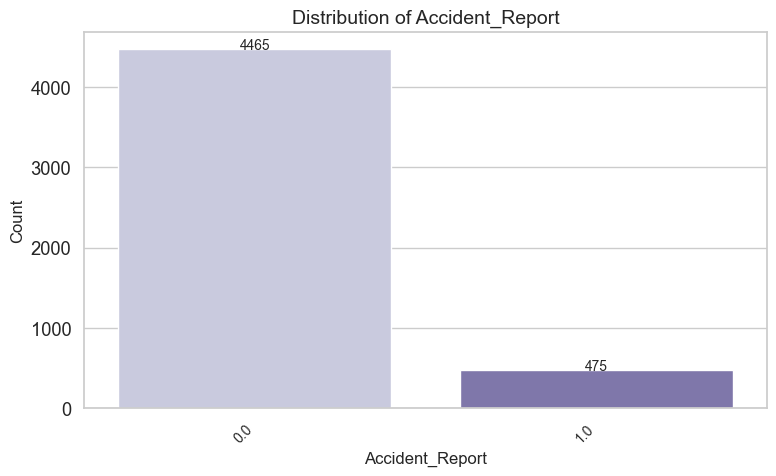


Balance Check for 'Traffic_Condition':
Counts:
 Traffic_Condition
High      3138
Medium    1454
Low        358
Name: count, dtype: int64
Percentages:
 Traffic_Condition
High      62.76
Medium    29.08
Low        7.16
Name: count, dtype: float64
Imbalance Ratio (max/min): 8.77
-> Highly Imbalanced


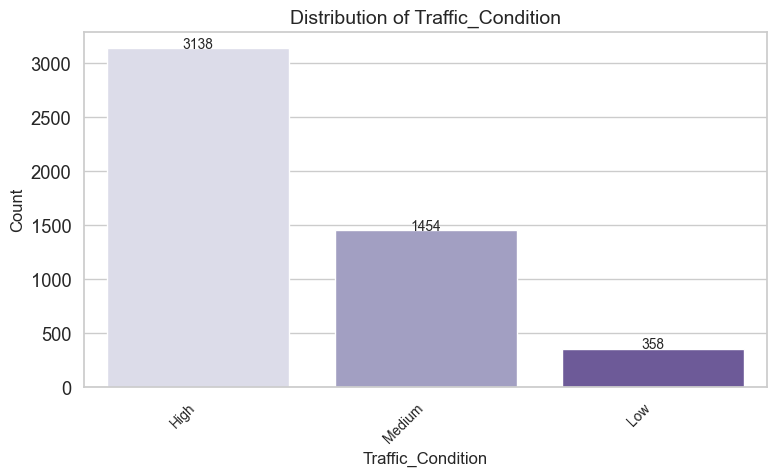

In [ ]:
## Checking if the dataset is balanced
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define categorical columns
categorical_cols = ['Traffic_Light_State', 'Weather_Condition', 'Accident_Report', 'Traffic_Condition']

# Function to check balance
def check_balance(df, column):
    # Count frequencies
    counts = df[column].value_counts()
    total = len(df)
    percentages = (counts / total * 100).round(2)

    # Metrics for imbalance
    max_count = counts.max()
    min_count = counts.min()
    imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')

    # Print results
    print(f"\nBalance Check for '{column}':")
    print("Counts:\n", counts)
    print("Percentages:\n", percentages)
    print(f"Imbalance Ratio (max/min): {imbalance_ratio:.2f}")
    if imbalance_ratio <= 1.5:
        print("-> Relatively Balanced")
    elif imbalance_ratio <= 3:
        print("-> Moderately Imbalanced")
    else:
        print("-> Highly Imbalanced")

    # Visualize
    plt.figure(figsize=(8, 5))
    sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette='Purples', legend=False)
    plt.title(f'Distribution of {column}', fontsize=14)
    plt.xlabel(column, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    for i, v in enumerate(counts.values):
        plt.text(i, v + 0.5, str(v), ha='center', fontsize=10)
    plt.tight_layout()
    plt.show()

# Check balance for each categorical column
for col in categorical_cols:
    check_balance(df, col)

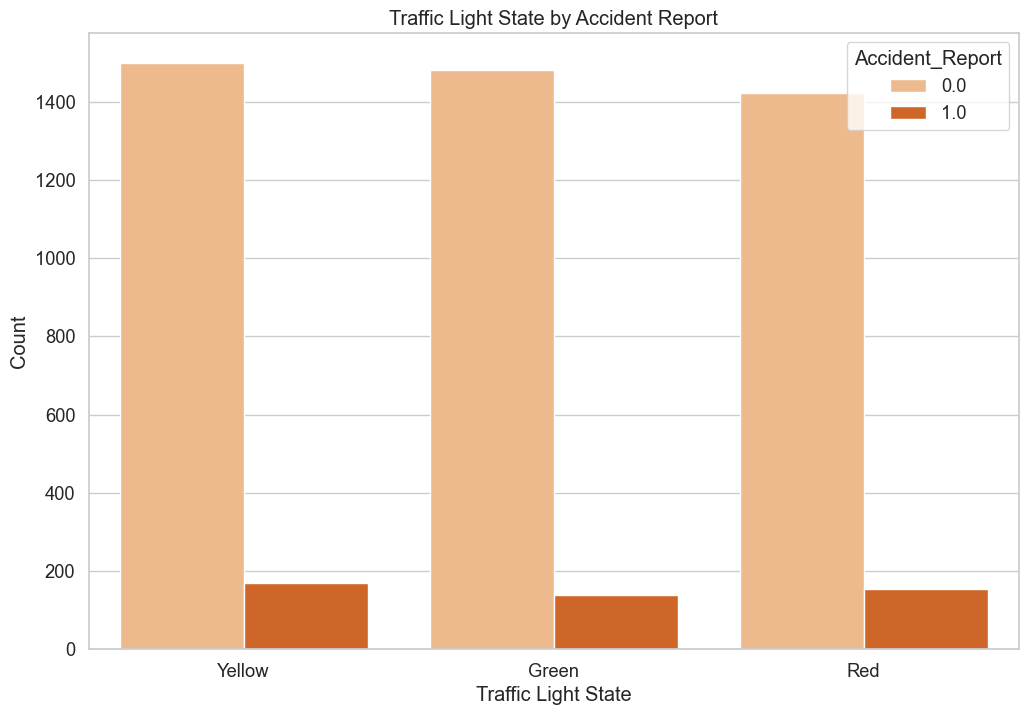

In [ ]:
# Visualizations
plt.figure(figsize=(12, 8))
sns.countplot(x='Traffic_Light_State', hue='Accident_Report', data=df, palette='Oranges')
plt.title('Traffic Light State by Accident Report')
plt.xlabel('Traffic Light State')
plt.ylabel('Count')
plt.show()

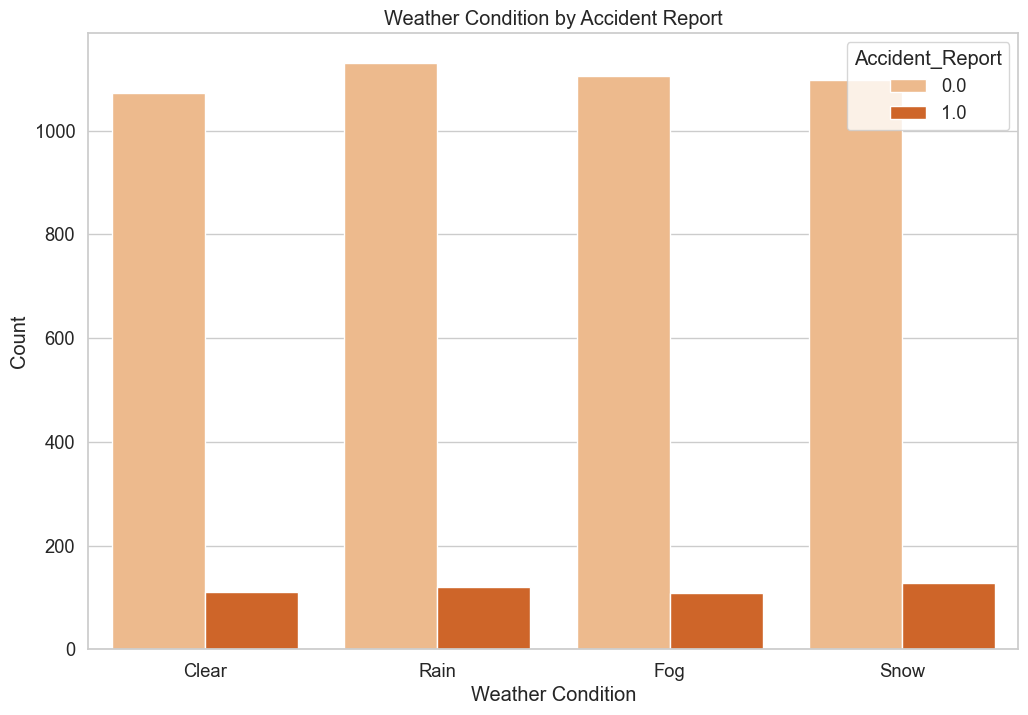

In [ ]:
# Visualizations
plt.figure(figsize=(12, 8))
sns.countplot(x='Weather_Condition', hue='Accident_Report', data=df, palette='Oranges')
plt.title('Weather Condition by Accident Report')
plt.xlabel('Weather Condition')
plt.ylabel('Count')
plt.show()

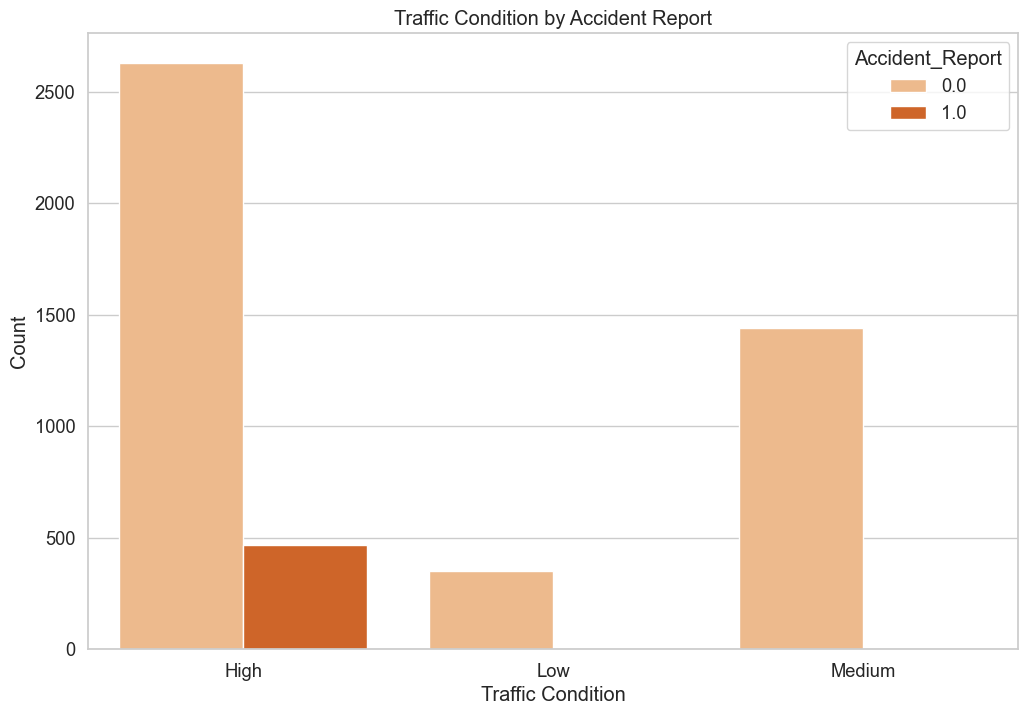

In [ ]:
# Visualizations
plt.figure(figsize=(12, 8))
sns.countplot(x='Traffic_Condition', hue='Accident_Report', data=df, palette='Oranges')
plt.title('Traffic Condition by Accident Report')
plt.xlabel('Traffic Condition')
plt.ylabel('Count')
plt.show()

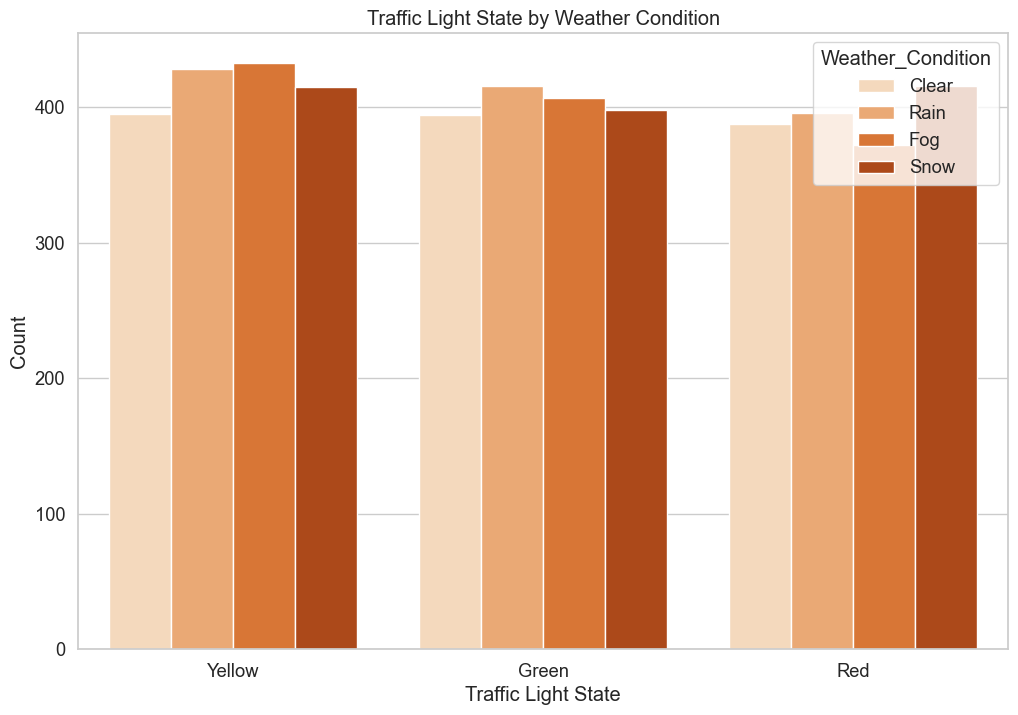

In [ ]:
# Visualizations
plt.figure(figsize=(12, 8))
sns.countplot(x='Traffic_Light_State', hue='Weather_Condition', data=df, palette='Oranges')
plt.title('Traffic Light State by Weather Condition')
plt.xlabel('Traffic Light State')
plt.ylabel('Count')
plt.show()

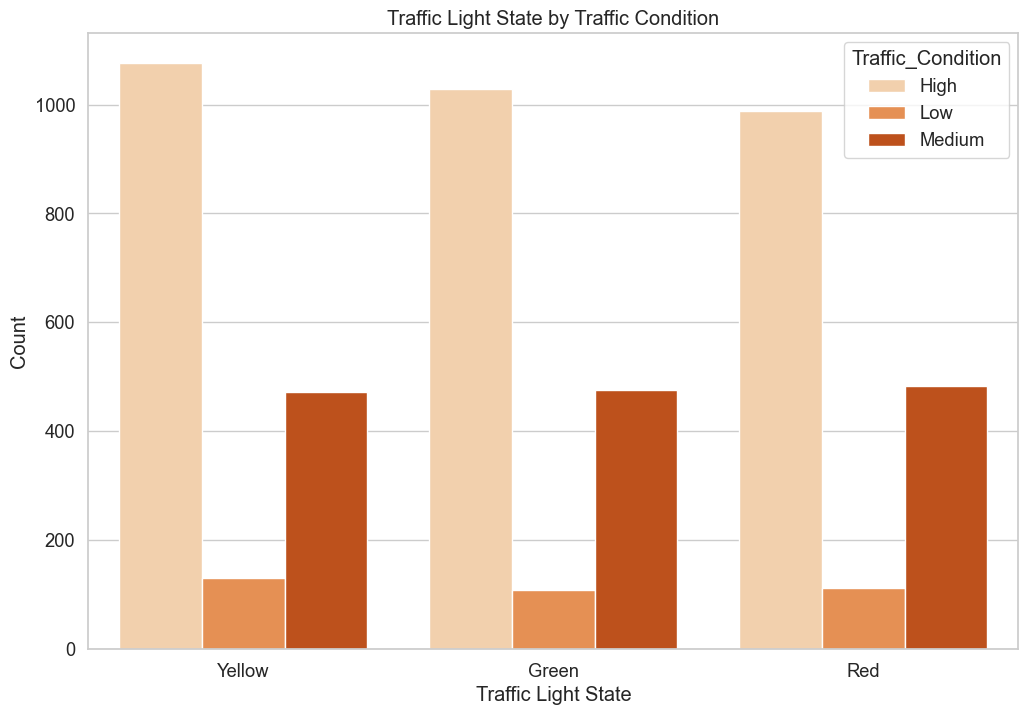

In [ ]:
# Visualizations
plt.figure(figsize=(12, 8))
sns.countplot(x='Traffic_Light_State', hue='Traffic_Condition', data=df, palette='Oranges')
plt.title('Traffic Light State by Traffic Condition')
plt.xlabel('Traffic Light State')
plt.ylabel('Count')
plt.show()

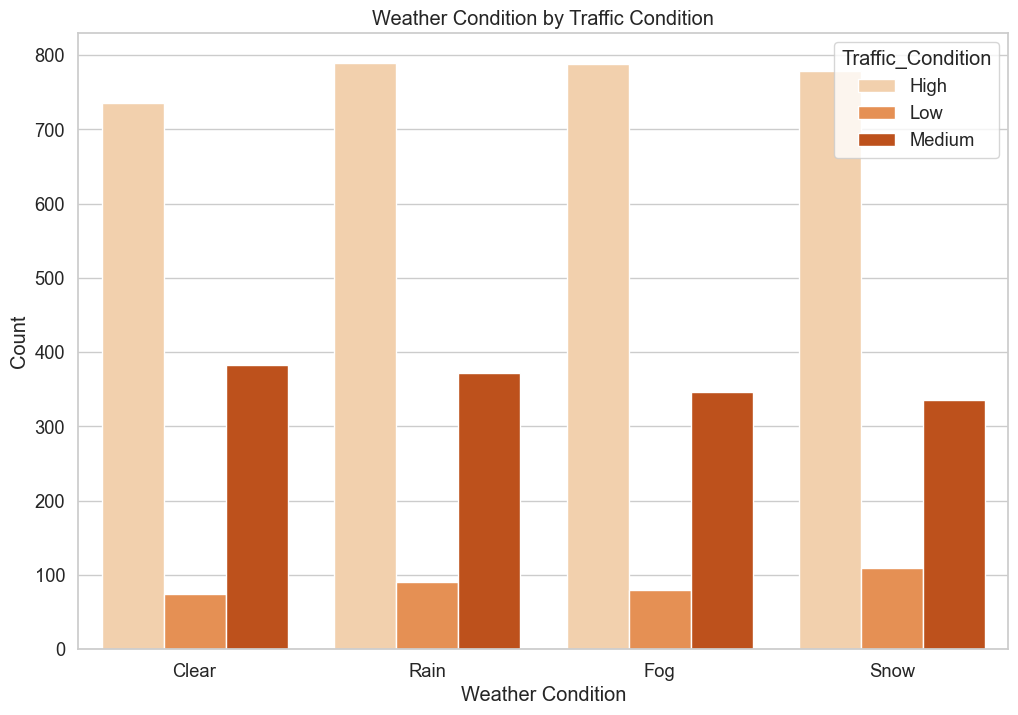

In [ ]:
# Visualizations
plt.figure(figsize=(12, 8))
sns.countplot(x='Weather_Condition', hue='Traffic_Condition', data=df, palette='Oranges')
plt.title('Weather Condition by Traffic Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Count')
plt.show()

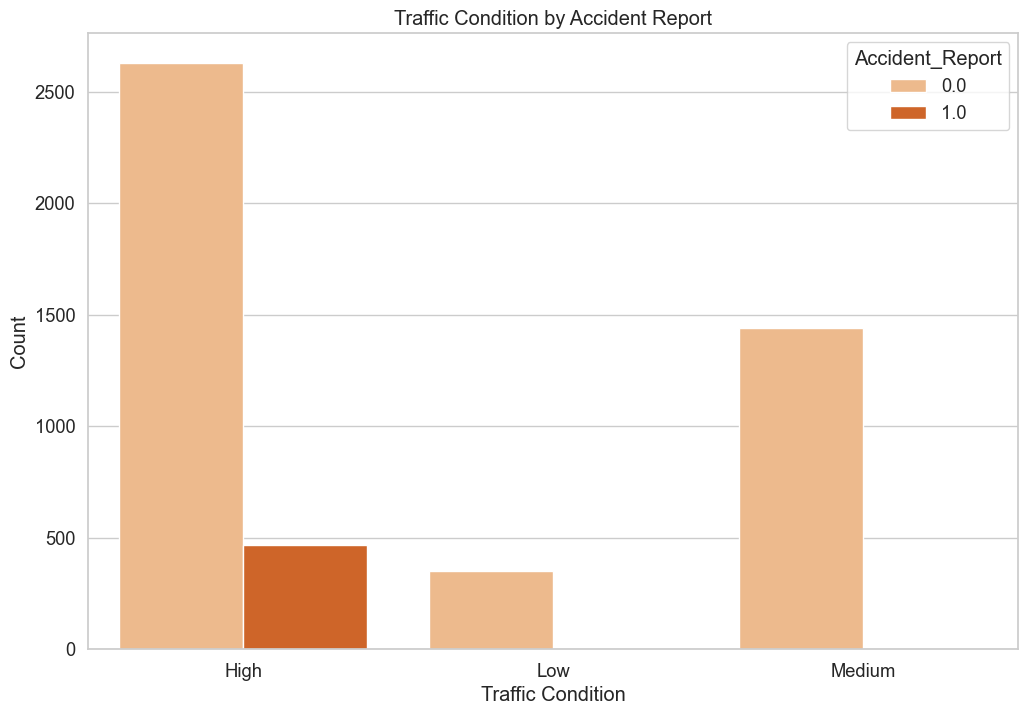

In [ ]:
# Visualizations for Traffic_Condition
plt.figure(figsize=(12, 8))
sns.countplot(x='Traffic_Condition', hue='Accident_Report', data=df, palette='Oranges')
plt.title('Traffic Condition by Accident Report')
plt.xlabel('Traffic Condition')
plt.ylabel('Count')
plt.show()

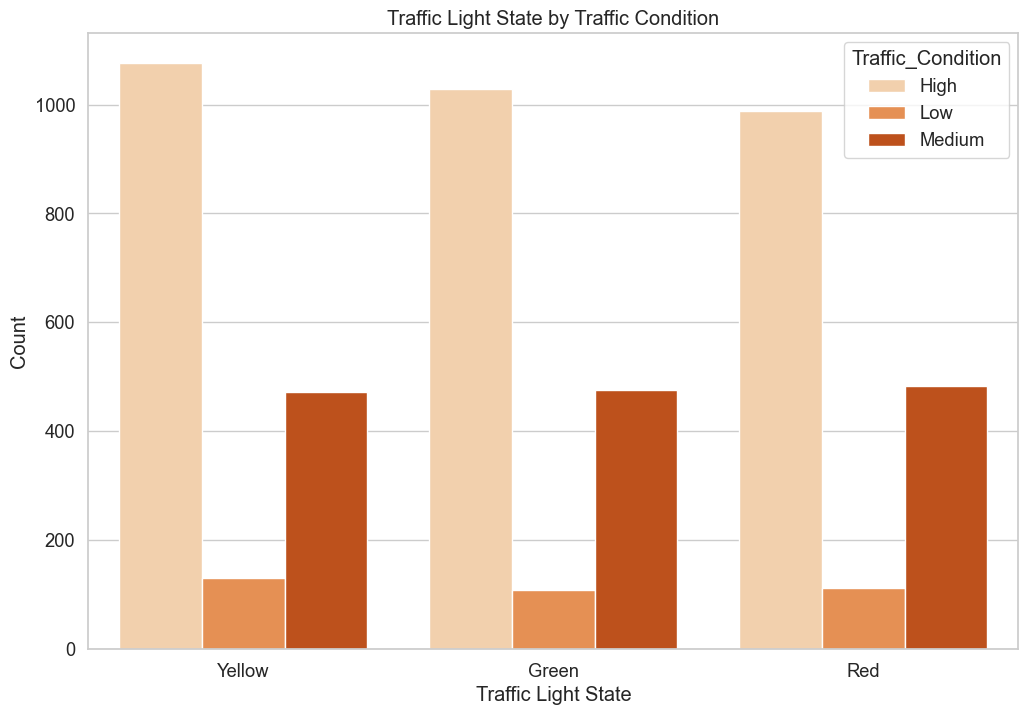

In [ ]:
# Visualizations
plt.figure(figsize=(12, 8))
sns.countplot(x='Traffic_Light_State', hue='Traffic_Condition', data=df, palette='Oranges')
plt.title('Traffic Light State by Traffic Condition')
plt.xlabel('Traffic Light State')
plt.ylabel('Count')
plt.show()

/var/folders/_f/952nnrtj2cqfx6j55v126fl80000gn/T/ipykernel_16497/3736368424.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Weather_Condition', y='Traffic_Speed_kmh', data=df, palette='Oranges')


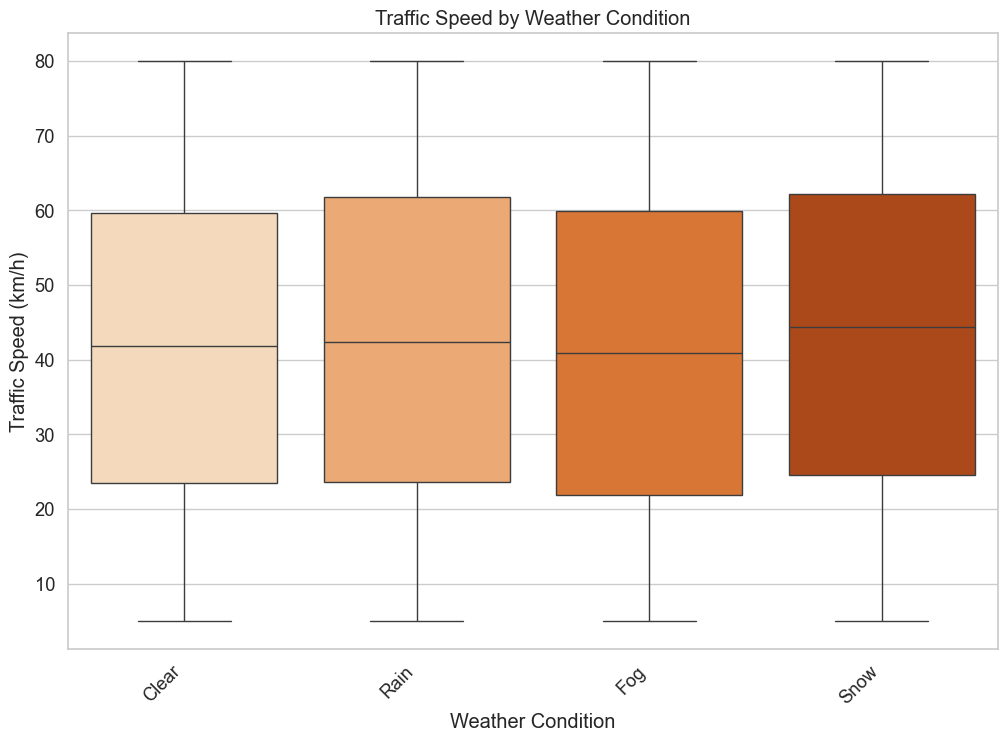

In [ ]:
# weather condition affecting traffic speed using boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(x='Weather_Condition', y='Traffic_Speed_kmh', data=df, palette='Oranges')
plt.title('Traffic Speed by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Traffic Speed (km/h)')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
# Check for constant columns
constant_cols = df.columns[df.nunique() == 1]
print("Constant Columns:", constant_cols)


Constant Columns: Index([], dtype='object')



Skewness:
Latitude                 -0.001739
Longitude                -0.052108
Vehicle_Count            -0.015535
Traffic_Speed_kmh         0.019578
Road_Occupancy_%          0.000431
Sentiment_Score           0.006666
Ride_Sharing_Demand       0.012975
Parking_Availability      0.006721
Emission_Levels_g_km      0.018016
Energy_Consumption_L_h    0.047860
dtype: float64

Kurtosis:
Latitude                 -1.202092
Longitude                -1.183599
Vehicle_Count            -1.206749
Traffic_Speed_kmh        -1.199238
Road_Occupancy_%         -1.202289
Sentiment_Score          -1.212059
Ride_Sharing_Demand      -1.177209
Parking_Availability     -1.207525
Emission_Levels_g_km     -1.186376
Energy_Consumption_L_h   -1.187501
dtype: float64


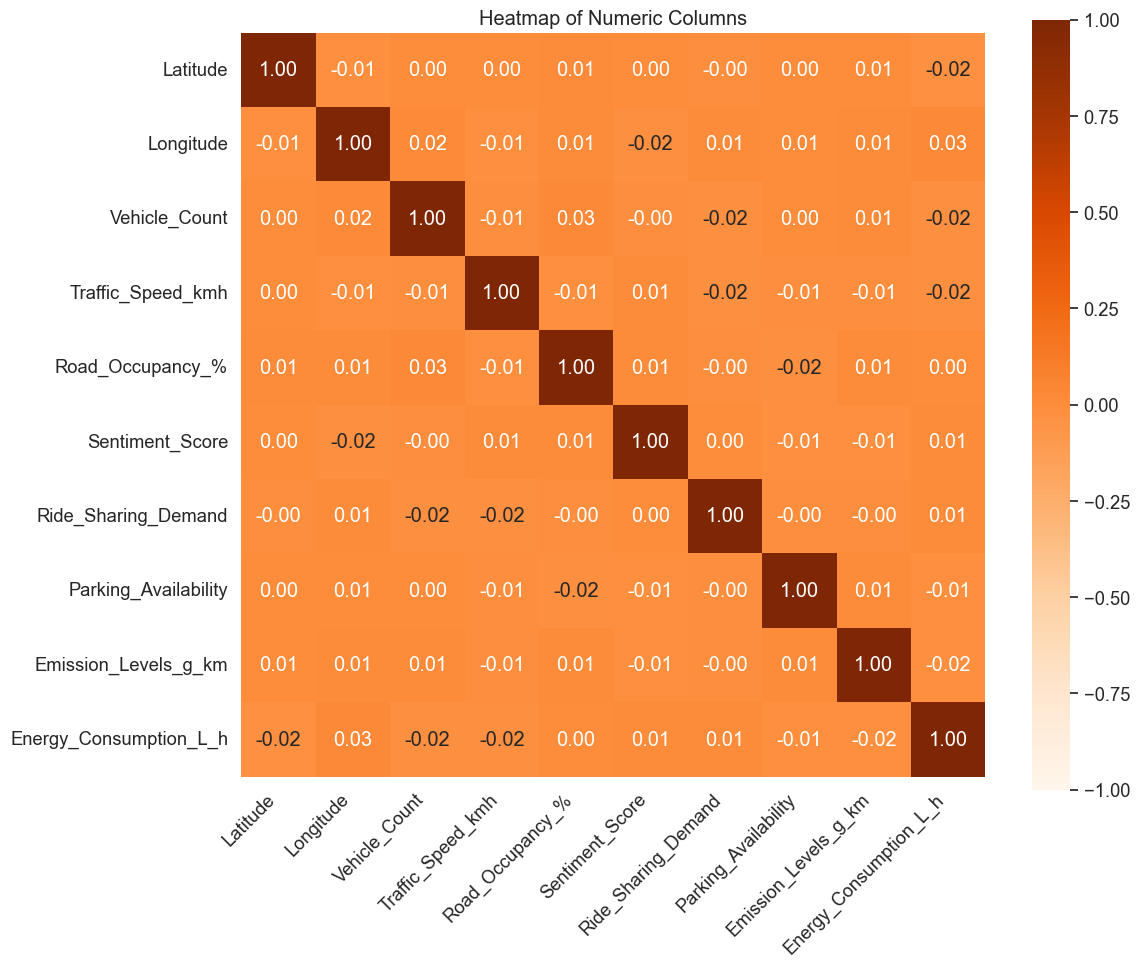

In [ ]:
valid_numerical_columns = ['Latitude', 'Longitude', 'Vehicle_Count', 'Traffic_Speed_kmh', 'Road_Occupancy_%', 'Sentiment_Score', 'Ride_Sharing_Demand', 'Parking_Availability', 'Emission_Levels_g_km', 'Energy_Consumption_L_h']

# Generate detailed descriptive statistics for numeric columns
desc_stats = df[valid_numerical_columns].describe().T

# Compute skewness for each numeric column
skewness = df[valid_numerical_columns].skew()
print("\nSkewness:")
print(skewness)

# Compute kurtosis for each numeric column
kurtosis = df[valid_numerical_columns].kurt()
print("\nKurtosis:")
print(kurtosis)

# Correlation matrix heatmap
heatmap_data = df[valid_numerical_columns].corr()    # Compute correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='Oranges', vmin=-1, vmax=1, fmt='.2f', square=True)
plt.title('Heatmap of Numeric Columns')
plt.xticks(rotation=45, ha='right')
plt.show()

## Inferential Statistics

H0: There is no significant difference between good and bad quality Apples
H1: There is a significant difference between good and bad quality Apples

In [ ]:
# T-test for Traffic_Speed_kmh by Traffic_Condition
from scipy import stats


In [ ]:
# Chi-square test for Traffic_Condition and Accident_Report
from scipy.stats import chi2_contingency
table = pd.crosstab(df['Traffic_Speed_kmh'], df['Accident_Report'])
chi2, p, dof, expected = chi2_contingency(table)
print(f"Chi-square (chi2),p-value(chi_p), Degrees of Freedom{dof}")

print(f"Chi-square Test: p-value={p:.4f}")

Chi-square (chi2),p-value(chi_p), Degrees of Freedom4870
Chi-square Test: p-value=0.4933


In [ ]:
# ANOVA for Traffic_Speed_kmh by Traffic_Condition
from scipy.stats import f_oneway    # Import ANOVA function


In [ ]:
# Confidence Interval for Traffic_Speed_kmh
from scipy.stats import t
import numpy as np  # Import numpy for array operations
